# Packages

In [23]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle
import wandb

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
import functions_enc as f
import function_depot as fd

# 123e1e2 Super test Heatmaps

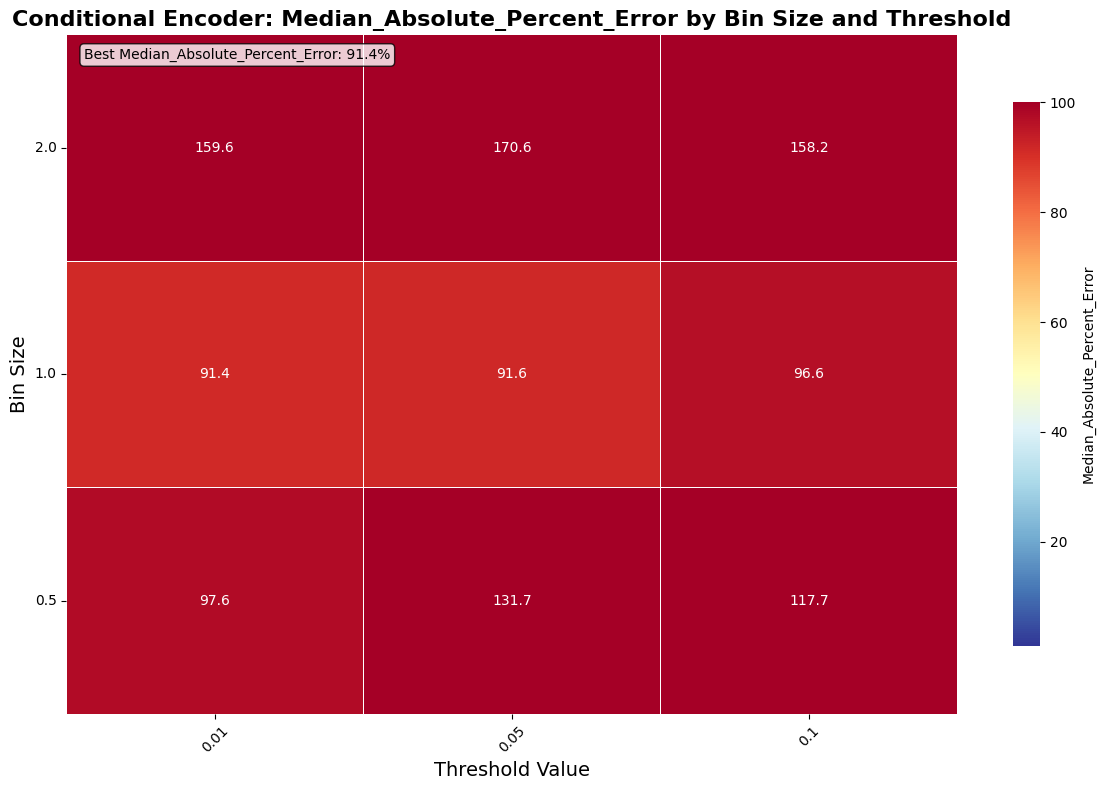

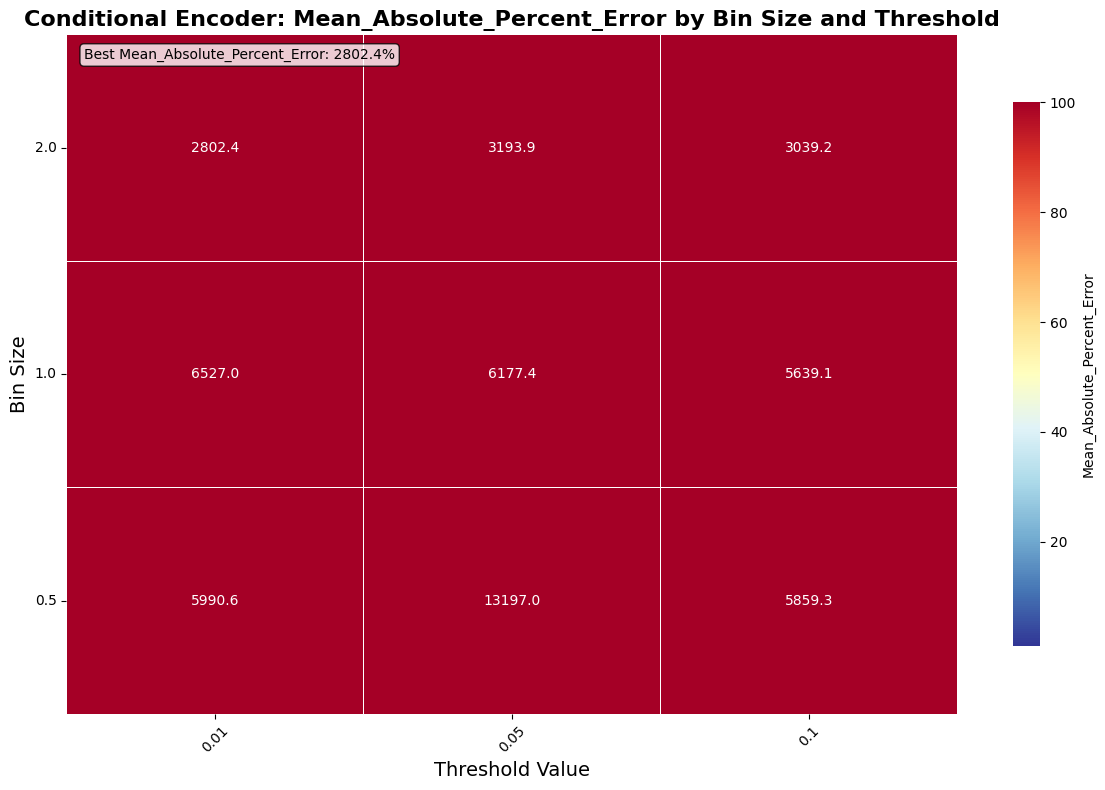

In [ ]:
# Small Heatmap
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load conditional encoder datasets folder path
cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/current_cond_enc_supertest_outputs"

# Get all .parquet files in the folder
cond_enc_parquet_files = [f for f in os.listdir(cond_enc_folder) if f.endswith('.parquet')]
cond_enc_dataset_names = [f.replace('.parquet', '') for f in cond_enc_parquet_files]

# Initialize storage for conditional encoder results (percent error only)
cond_enc_results_percent_error = []

# Process conditional encoder datasets
for i, dataset_name in enumerate(sorted(cond_enc_dataset_names), 1):
    try:
        # Load the conditional encoder dataset
        file_path = os.path.join(cond_enc_folder, f"{dataset_name}.parquet")
        df = pd.read_parquet(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:  # Skip if too few samples
            continue
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate median and mean absolute percent error
        median_percent_error = np.median(individual_errors)
        mean_percent_error = np.mean(individual_errors)
        
        # Store results
        cond_enc_results_percent_error.append({
            'Dataset': dataset_name,
            'Median_Percent_Error': median_percent_error,
            'Mean_Percent_Error': mean_percent_error,
            'Samples': len(y_pred_response_clean)
        })
        
    except Exception as e:
        continue

# Convert results to DataFrame
df_cond_enc_percent_error_results = pd.DataFrame(cond_enc_results_percent_error)

# Function to parse conditional encoder dataset names
def parse_cond_enc_dataset_name(dataset_name):
    """Extract bin size and threshold from full conditional encoder dataset name"""
    # Remove 'cond_enc_full2_' prefix
    name_part = dataset_name.replace('super_test_cond_enc_', '') 
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns
bin_sizes = []
thresholds = []

for dataset_name in df_cond_enc_percent_error_results['Dataset']:
    bin_size, threshold = parse_cond_enc_dataset_name(dataset_name)
    bin_sizes.append(bin_size)
    thresholds.append(threshold)

df_cond_enc_percent_error_results['BinSize'] = bin_sizes
df_cond_enc_percent_error_results['Threshold'] = thresholds

# Remove duplicates
df_cond_enc_percent_error_results = df_cond_enc_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

# Create pivot tables
cond_enc_median_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Median_Percent_Error')
cond_enc_mean_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Mean_Percent_Error')

# # # List all expected thresholds and bin sizes
# thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
# bins_subset = [0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# List all expected thresholds and bin sizes
bins_subset = [0.5, 1, 2] # 0.5,
thresholds_subset = [0.01, 0.05, 0.1] #  0.05,

# Reindex pivot tables
cond_enc_median_percent_error_pivot = cond_enc_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
cond_enc_mean_percent_error_pivot = cond_enc_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Function to create heatmaps
def create_detailed_heatmap_cond_enc(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single Conditional Encoder metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'{metric_name}', 'shrink': 0.8})
    
    plt.title(f'Conditional Encoder: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_val = pivot_data.min().min()
    plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    # plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/CondEnc_{metric_name}_by_Bin_Size_and_Threshold.png", 
    #             dpi=300, bbox_inches='tight')
    plt.show()

# Create heatmaps
create_detailed_heatmap_cond_enc(cond_enc_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_cond_enc(cond_enc_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

# Newest Regular Test Heatmaps

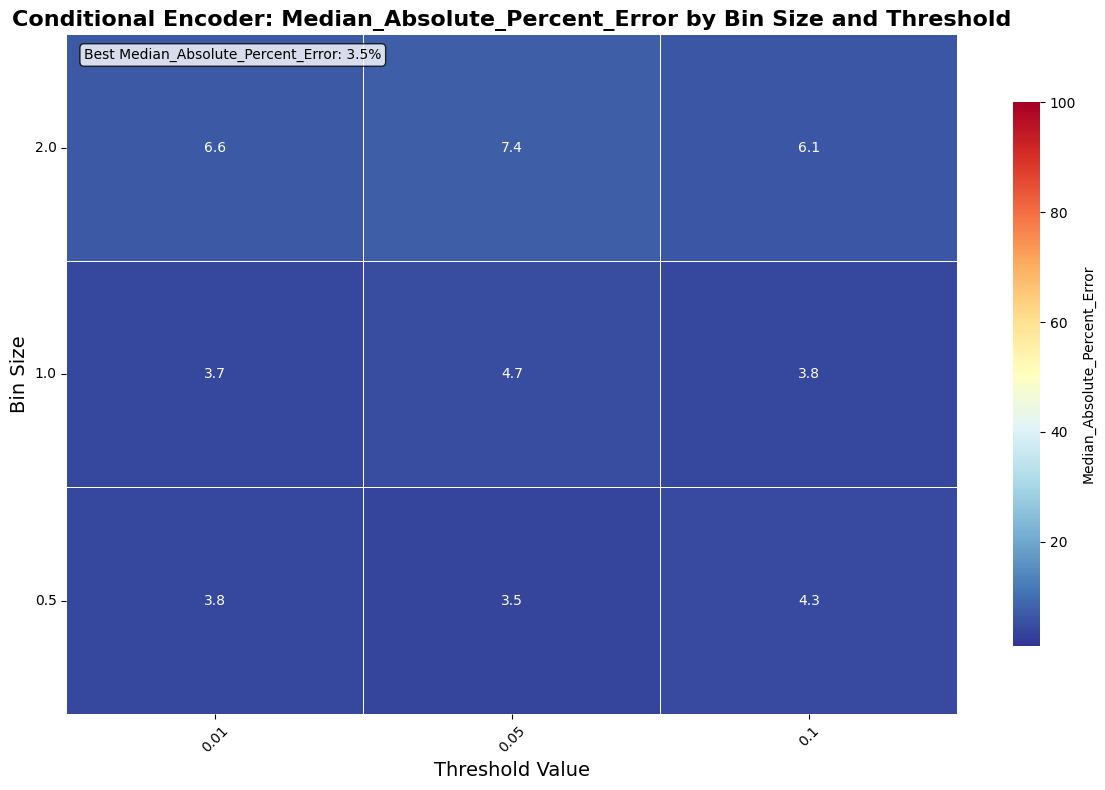

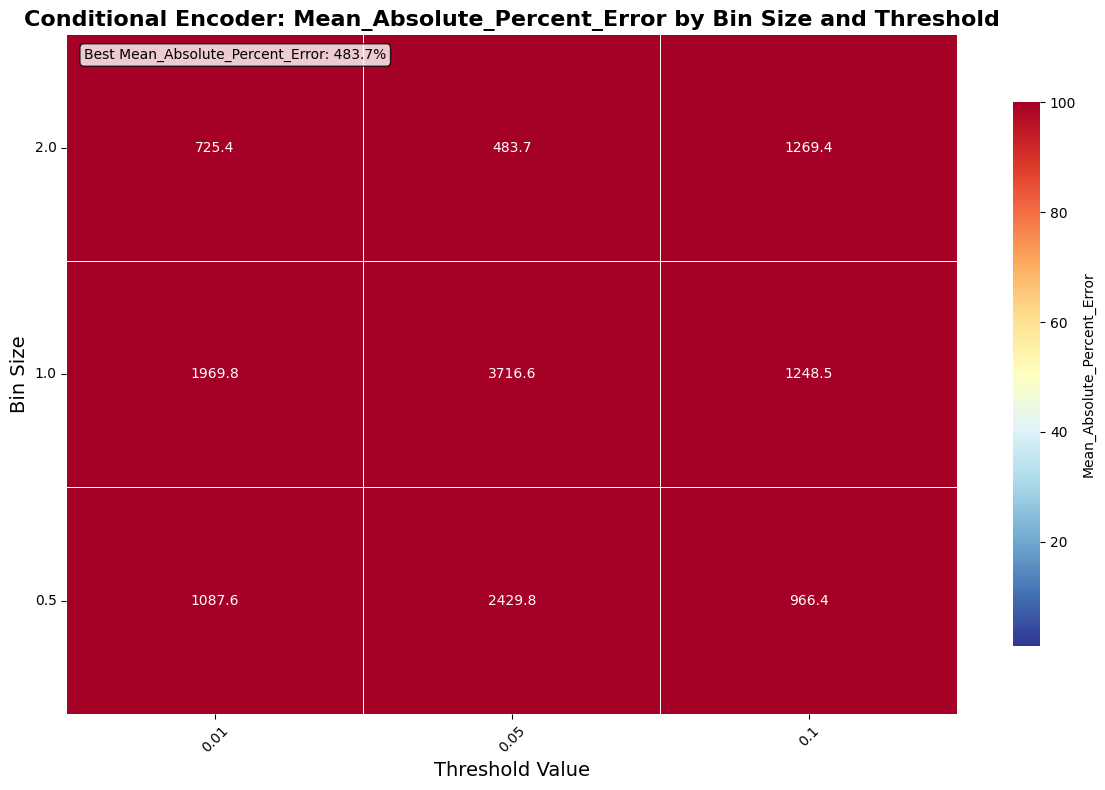

In [2]:
# Small Heatmap
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load conditional encoder datasets folder path
cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_outputs_df6"

# Get all .parquet files in the folder
cond_enc_parquet_files = [f for f in os.listdir(cond_enc_folder) if f.endswith('.parquet')]
cond_enc_dataset_names = [f.replace('.parquet', '') for f in cond_enc_parquet_files]

# Initialize storage for conditional encoder results (percent error only)
cond_enc_results_percent_error = []

# Process conditional encoder datasets
for i, dataset_name in enumerate(sorted(cond_enc_dataset_names), 1):
    try:
        # Load the conditional encoder dataset
        file_path = os.path.join(cond_enc_folder, f"{dataset_name}.parquet")
        df = pd.read_parquet(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:  # Skip if too few samples
            continue
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate median and mean absolute percent error
        median_percent_error = np.median(individual_errors)
        mean_percent_error = np.mean(individual_errors)
        
        # Store results
        cond_enc_results_percent_error.append({
            'Dataset': dataset_name,
            'Median_Percent_Error': median_percent_error,
            'Mean_Percent_Error': mean_percent_error,
            'Samples': len(y_pred_response_clean)
        })
        
    except Exception as e:
        continue

# Convert results to DataFrame
df_cond_enc_percent_error_results = pd.DataFrame(cond_enc_results_percent_error)

# Function to parse conditional encoder dataset names
def parse_cond_enc_dataset_name(dataset_name):
    """Extract bin size and threshold from full conditional encoder dataset name"""
    # Remove 'cond_enc_full2_' prefix
    name_part = dataset_name.replace('cond_enc_', '') # NEEDS CHANGE
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns
bin_sizes = []
thresholds = []

for dataset_name in df_cond_enc_percent_error_results['Dataset']:
    bin_size, threshold = parse_cond_enc_dataset_name(dataset_name)
    bin_sizes.append(bin_size)
    thresholds.append(threshold)

df_cond_enc_percent_error_results['BinSize'] = bin_sizes
df_cond_enc_percent_error_results['Threshold'] = thresholds

# Remove duplicates
df_cond_enc_percent_error_results = df_cond_enc_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

# Create pivot tables
cond_enc_median_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Median_Percent_Error')
cond_enc_mean_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Mean_Percent_Error')

# # List all expected thresholds and bin sizes
# thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
# bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# List all expected thresholds and bin sizes
bins_subset = [0.5, 1, 2] # 0.5,
thresholds_subset = [0.01, 0.05, 0.1] #  0.05,

# Reindex pivot tables
cond_enc_median_percent_error_pivot = cond_enc_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
cond_enc_mean_percent_error_pivot = cond_enc_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Function to create heatmaps
def create_detailed_heatmap_cond_enc(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single Conditional Encoder metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'{metric_name}', 'shrink': 0.8})
    
    plt.title(f'Conditional Encoder: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_val = pivot_data.min().min()
    plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    # plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/CondEnc_{metric_name}_by_Bin_Size_and_Threshold.png", 
    #             dpi=300, bbox_inches='tight')
    plt.show()

# Create heatmaps
create_detailed_heatmap_cond_enc(cond_enc_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_cond_enc(cond_enc_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

# Newest Error Investigations - Super Test Set

Loading data for bin_size=1, threshold=0.1


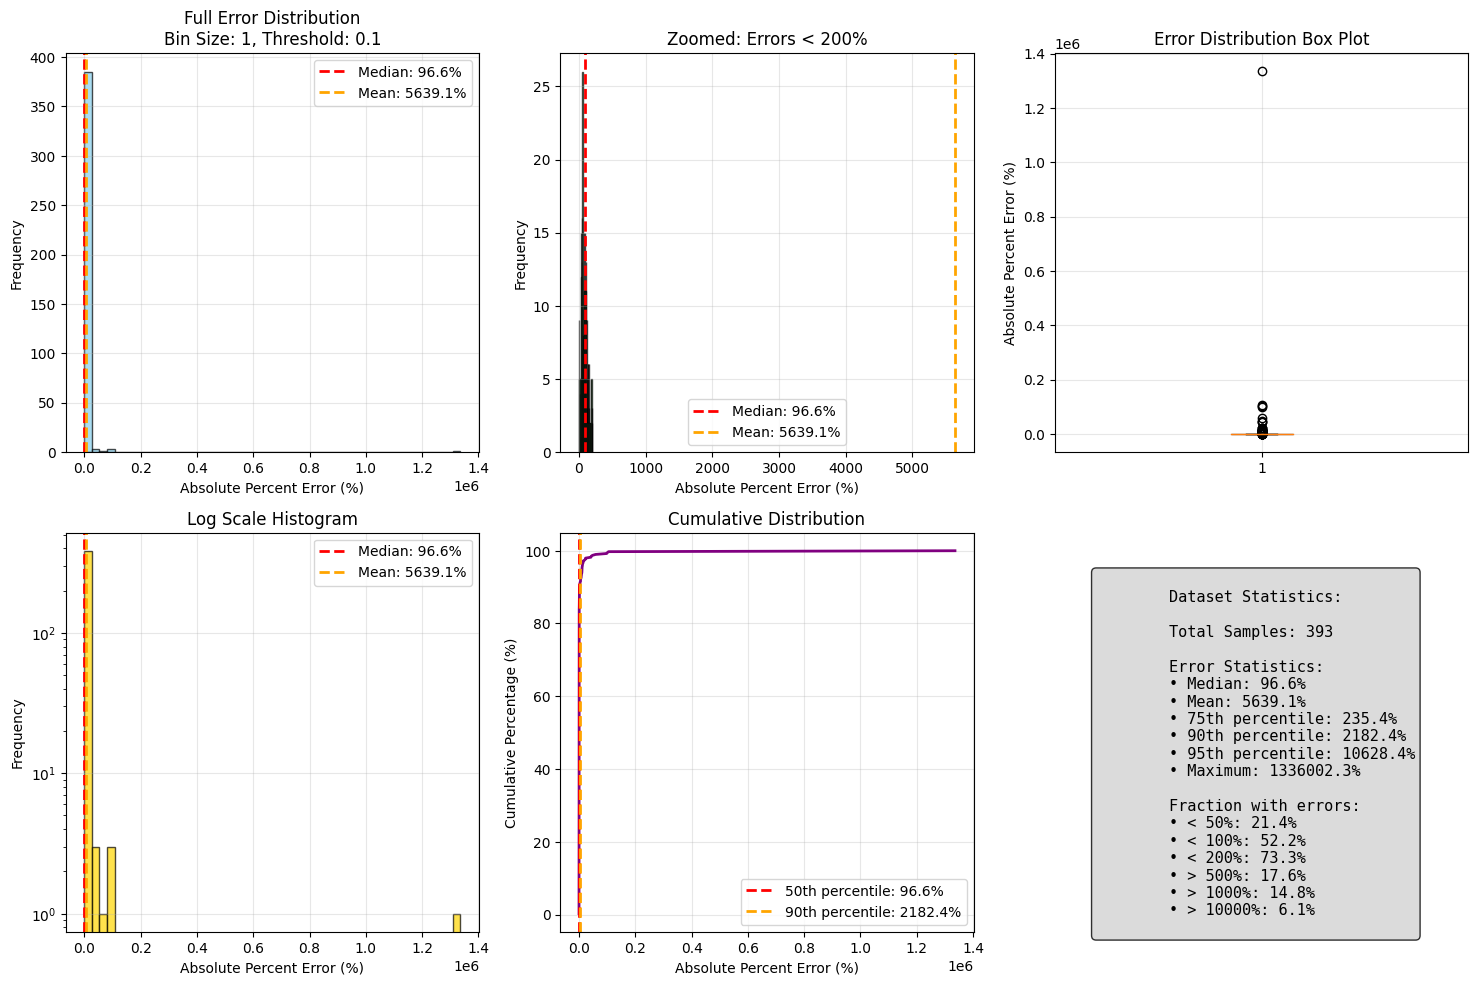


Outlier Analysis:
Number of outliers (>10628.4%): 20 / 393

Extreme Error Analysis:
Errors > 1000%: 58 / 393 (14.76%)
Errors > 10000%: 24 / 393 (6.11%)

Worst 20 predictions:
   1. True:    0.158, Pred: 2109.674, Error: 1336002.3%
   2. True:    0.158, Pred:  165.888, Error: 104960.2%
   3. True:    0.158, Pred:  159.341, Error: 100814.2%
   4. True:    4.800, Pred: 4720.847, Error:  98251.0%
   5. True:    0.158, Pred:   93.075, Error:  58846.6%
   6. True:    3.000, Pred: 1432.263, Error:  47642.1%
   7. True:    3.000, Pred: 1298.775, Error:  43192.5%
   8. True:    3.000, Pred: 1272.788, Error:  42326.3%
   9. True:    4.800, Pred: 1111.609, Error:  23058.5%
  10. True:    4.800, Pred: 1111.609, Error:  23058.5%
  11. True:   24.200, Pred: 4900.036, Error:  20148.1%
  12. True:   29.980, Pred: 4558.872, Error:  15106.4%
  13. True:   19.524, Pred: 2964.502, Error:  15083.9%
  14. True:   29.980, Pred: 4359.941, Error:  14442.9%
  15. True:   24.200, Pred: 3179.114, Error:  13036.8

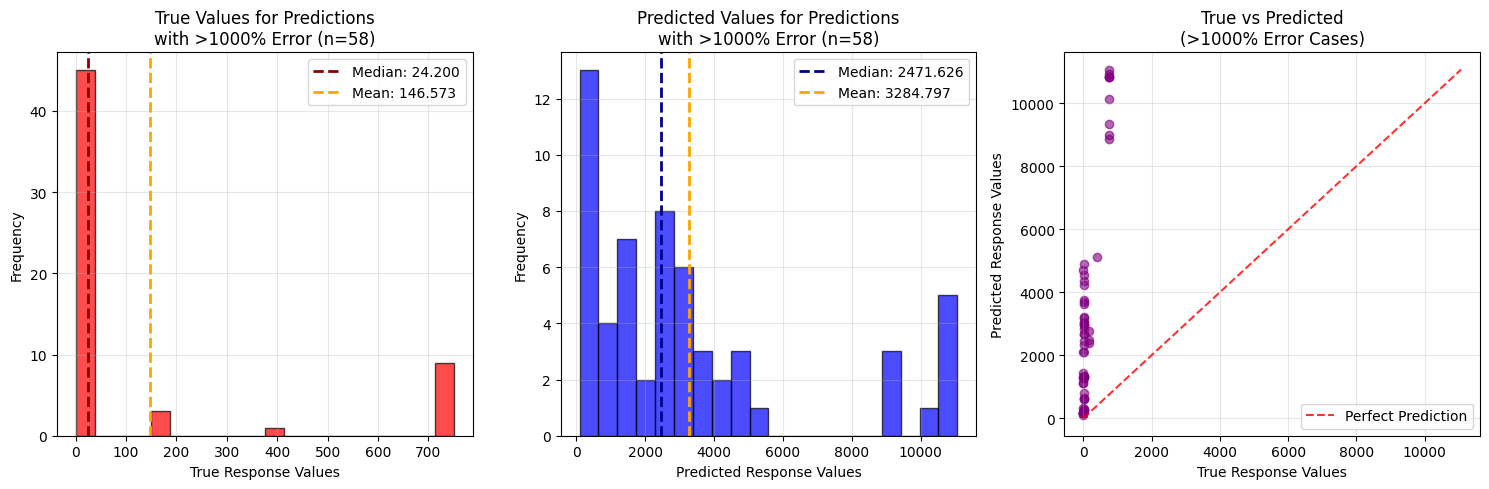


Statistics for predictions with >1000% error:
True values  - Min: 0.158, Max: 750.000, Median: 24.200, Mean: 146.573
Pred values  - Min: 93.075, Max: 11069.077, Median: 2471.626, Mean: 3284.797

Value range analysis for >1000% errors:
True values < 1: 4 / 58 (6.9%)
True values > 100: 13 / 58 (22.4%)


In [ ]:
def plot_error_distribution_for_dataset(bin_size, threshold, data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/current_cond_enc_supertest_outputs"):
    """
    Generate a histogram showing the error distribution for a specific bin size and threshold.
    
    Parameters:
    -----------
    bin_size : float
        The bin size (e.g., 1, 5, 100, 1000)
    threshold : float  
        The threshold value (e.g., 0, 0.001, 0.1, 100)
    data_folder : str
        Path to the folder containing conditional encoder output files
    """
    
    # Convert bin_size and threshold to string format used in filenames
    if bin_size < 1:
        bin_str = f"bin{str(bin_size).replace('.', '_')}"
    else:
        bin_str = f"bin{int(bin_size)}"
    
    if threshold == 0:
        thresh_str = "thresh_zero"
    elif threshold < 1:
        thresh_str = f"thresh{str(threshold).replace('.', '_')}"
    else:
        thresh_str = f"thresh{int(threshold)}"
    
    # Construct filename
    dataset_name = f"super_test_cond_enc_{bin_str}_{thresh_str}_df_spectra"
    filename = f"{dataset_name}.parquet"
    file_path = os.path.join(data_folder, filename)
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"File not found: {filename}")
        print(f"Looking in: {data_folder}")
        return None
    
    try:
        # Load the data
        print(f"Loading data for bin_size={bin_size}, threshold={threshold}")
        df = pd.read_parquet(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:
            print(f"Too few valid samples: {len(y_pred_response_clean)}")
            return None
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate statistics
        median_error = np.median(individual_errors)
        mean_error = np.mean(individual_errors)
        q75_error = np.percentile(individual_errors, 75)
        q90_error = np.percentile(individual_errors, 90)
        q95_error = np.percentile(individual_errors, 95)
        max_error = np.max(individual_errors)
        
        # Create the histogram plot
        plt.figure(figsize=(15, 10))
        
        # Main histogram (full range)
        plt.subplot(2, 3, 1)
        plt.hist(individual_errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'Median: {median_error:.1f}%')
        plt.axvline(mean_error, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Frequency')
        plt.title(f'Full Error Distribution\nBin Size: {bin_size}, Threshold: {threshold}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Zoomed histogram (errors < 200%)
        plt.subplot(2, 3, 2)
        errors_zoomed = individual_errors[individual_errors < 200]
        plt.hist(errors_zoomed, bins=40, alpha=0.7, color='lightgreen', edgecolor='black')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'Median: {median_error:.1f}%')
        plt.axvline(mean_error, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Frequency')
        plt.title('Zoomed: Errors < 200%')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Box plot
        plt.subplot(2, 3, 3)
        plt.boxplot(individual_errors, patch_artist=True, 
                   boxprops=dict(facecolor='lightcoral', alpha=0.7))
        plt.ylabel('Absolute Percent Error (%)')
        plt.title('Error Distribution Box Plot')
        plt.grid(True, alpha=0.3)
        
        # Log scale histogram
        plt.subplot(2, 3, 4)
        plt.hist(individual_errors, bins=50, alpha=0.7, color='gold', edgecolor='black')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'Median: {median_error:.1f}%')
        plt.axvline(mean_error, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Frequency')
        plt.yscale('log')
        plt.title('Log Scale Histogram')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Cumulative distribution
        plt.subplot(2, 3, 5)
        sorted_errors = np.sort(individual_errors)
        cumulative_percent = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
        plt.plot(sorted_errors, cumulative_percent, linewidth=2, color='purple')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'50th percentile: {median_error:.1f}%')
        plt.axvline(q90_error, color='orange', linestyle='--', linewidth=2, label=f'90th percentile: {q90_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Cumulative Percentage (%)')
        plt.title('Cumulative Distribution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Statistics text
        plt.subplot(2, 3, 6)
        plt.axis('off')
        stats_text = f"""
        Dataset Statistics:
        
        Total Samples: {len(individual_errors):,}
        
        Error Statistics:
        • Median: {median_error:.1f}%
        • Mean: {mean_error:.1f}%
        • 75th percentile: {q75_error:.1f}%
        • 90th percentile: {q90_error:.1f}%
        • 95th percentile: {q95_error:.1f}%
        • Maximum: {max_error:.1f}%
        
        Fraction with errors:
        • < 50%: {(individual_errors < 50).mean()*100:.1f}%
        • < 100%: {(individual_errors < 100).mean()*100:.1f}%
        • < 200%: {(individual_errors < 200).mean()*100:.1f}%
        • > 500%: {(individual_errors > 500).mean()*100:.1f}%
        • > 1000%: {(individual_errors > 1000).mean()*100:.1f}%
        • > 10000%: {(individual_errors > 10000).mean()*100:.1f}%
        """
        plt.text(0.1, 0.9, stats_text, transform=plt.gca().transAxes, 
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Print outlier information
        print(f"\nOutlier Analysis:")
        outlier_threshold = q95_error
        outliers = individual_errors > outlier_threshold
        print(f"Number of outliers (>{outlier_threshold:.1f}%): {outliers.sum()} / {len(individual_errors)}")
        
        # Print extreme outlier statistics
        print(f"\nExtreme Error Analysis:")
        print(f"Errors > 1000%: {(individual_errors > 1000).sum()} / {len(individual_errors)} ({(individual_errors > 1000).mean()*100:.2f}%)")
        print(f"Errors > 10000%: {(individual_errors > 10000).sum()} / {len(individual_errors)} ({(individual_errors > 10000).mean()*100:.2f}%)")
        
        # Show worst 20 predictions (instead of just 5)
        if len(individual_errors) > 0:
            print(f"\nWorst 20 predictions:")
            worst_indices = np.argsort(individual_errors)[-20:][::-1]
            for i, idx in enumerate(worst_indices):
                print(f"  {i+1:2d}. True: {y_true_response_clean.iloc[idx]:8.3f}, "
                      f"Pred: {y_pred_response_clean.iloc[idx]:8.3f}, "
                      f"Error: {individual_errors[idx]:8.1f}%")
        
        # Create histogram of true values for predictions with >1000% error
        extreme_error_mask = individual_errors > 1000
        if extreme_error_mask.sum() > 0:
            print(f"\nAnalyzing true values for {extreme_error_mask.sum()} predictions with >1000% error...")
            
            extreme_true_values = y_true_response_clean[extreme_error_mask]
            extreme_pred_values = y_pred_response_clean[extreme_error_mask]
            
            plt.figure(figsize=(15, 5))
            
            # Histogram of true values for extreme errors
            plt.subplot(1, 3, 1)
            plt.hist(extreme_true_values, bins=20, alpha=0.7, color='red', edgecolor='black')
            plt.xlabel('True Response Values')
            plt.ylabel('Frequency')
            plt.title(f'True Values for Predictions\nwith >1000% Error (n={extreme_error_mask.sum()})')
            plt.grid(True, alpha=0.3)
            
            # Add statistics
            plt.axvline(np.median(extreme_true_values), color='darkred', linestyle='--', 
                       linewidth=2, label=f'Median: {np.median(extreme_true_values):.3f}')
            plt.axvline(np.mean(extreme_true_values), color='orange', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(extreme_true_values):.3f}')
            plt.legend()
            
            # Histogram of predicted values for extreme errors
            plt.subplot(1, 3, 2)
            plt.hist(extreme_pred_values, bins=20, alpha=0.7, color='blue', edgecolor='black')
            plt.xlabel('Predicted Response Values')
            plt.ylabel('Frequency')
            plt.title(f'Predicted Values for Predictions\nwith >1000% Error (n={extreme_error_mask.sum()})')
            plt.grid(True, alpha=0.3)
            
            # Add statistics
            plt.axvline(np.median(extreme_pred_values), color='darkblue', linestyle='--', 
                       linewidth=2, label=f'Median: {np.median(extreme_pred_values):.3f}')
            plt.axvline(np.mean(extreme_pred_values), color='orange', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(extreme_pred_values):.3f}')
            plt.legend()
            
            # Scatter plot: True vs Predicted for extreme errors
            plt.subplot(1, 3, 3)
            plt.scatter(extreme_true_values, extreme_pred_values, alpha=0.6, color='purple')
            plt.xlabel('True Response Values')
            plt.ylabel('Predicted Response Values')
            plt.title('True vs Predicted\n(>1000% Error Cases)')
            plt.grid(True, alpha=0.3)
            
            # Add diagonal line
            min_val = min(extreme_true_values.min(), extreme_pred_values.min())
            max_val = max(extreme_true_values.max(), extreme_pred_values.max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect Prediction')
            plt.legend()
            
            plt.tight_layout()
            plt.show()
            
            # Print statistics for extreme error cases
            print(f"\nStatistics for predictions with >1000% error:")
            print(f"True values  - Min: {extreme_true_values.min():.3f}, Max: {extreme_true_values.max():.3f}, "
                  f"Median: {np.median(extreme_true_values):.3f}, Mean: {np.mean(extreme_true_values):.3f}")
            print(f"Pred values  - Min: {extreme_pred_values.min():.3f}, Max: {extreme_pred_values.max():.3f}, "
                  f"Median: {np.median(extreme_pred_values):.3f}, Mean: {np.mean(extreme_pred_values):.3f}")
            
            # Check if extreme errors are associated with specific value ranges
            print(f"\nValue range analysis for >1000% errors:")
            print(f"True values < 1: {(extreme_true_values < 1).sum()} / {len(extreme_true_values)} ({(extreme_true_values < 1).mean()*100:.1f}%)")
            print(f"True values > 100: {(extreme_true_values > 100).sum()} / {len(extreme_true_values)} ({(extreme_true_values > 100).mean()*100:.1f}%)")
        else:
            print(f"\nNo predictions with >1000% error found.")
        
        return individual_errors
        
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        return None

# Plot error distribution 
errors = plot_error_distribution_for_dataset(bin_size=1, threshold=0.1, data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/current_cond_enc_supertest_outputs")

# Plot error distribution for bin size 1000, threshold 0 (no threshold)
# errors = plot_error_distribution_for_dataset(bin_size=1000, threshold=0)

# Plot error distribution for bin size 0.1, threshold 0.001
# errors = plot_error_distribution_for_dataset(bin_size=0.1, threshold=0.001)

In [ ]:
def analyze_worst_predictions(bin_size=1, threshold=0.1, error_threshold=1000, toxicity_benchmark=50, 
                             data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/current_cond_enc_supertest_outputs"):
    """
    Analyze worst predictions and proportion of low toxicity chemicals with high errors.
    
    Parameters:
    -----------
    bin_size : float
        The bin size (e.g., 1, 5, 100, 1000)
    threshold : float  
        The threshold value (e.g., 0, 0.001, 0.1, 100)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
        
    Returns:
    --------
    dict : Dictionary containing analysis results
    """
    
    # Convert bin_size and threshold to string format used in filenames
    if bin_size < 1:
        bin_str = f"bin{str(bin_size).replace('.', '_')}"
    else:
        bin_str = f"bin{int(bin_size)}"
    
    if threshold == 0:
        thresh_str = "thresh_zero"
    elif threshold < 1:
        thresh_str = f"thresh{str(threshold).replace('.', '_')}"
    else:
        thresh_str = f"thresh{int(threshold)}"
    
    # Construct filename
    dataset_name = f"super_test_cond_enc_{bin_str}_{thresh_str}_df_spectra"
    filename = f"{dataset_name}.parquet"
    file_path = os.path.join(data_folder, filename)
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"File not found: {filename}")
        return None
    
    try:
        # Load the data
        print(f"Loading data for bin_size={bin_size}, threshold={threshold}")
        df = pd.read_parquet(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:
            print(f"Too few valid samples: {len(y_pred_response_clean)}")
            return None
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # === WORST 20 PREDICTIONS TABLE ===
        print(f"\n{'='*80}")
        print(f"WORST 20 PREDICTIONS (Bin Size: {bin_size}, Threshold: {threshold})")
        print(f"{'='*80}")
        
        worst_indices = np.argsort(individual_errors)[::-1][:20]  # Get 20 worst, highest error first
        
        print(f"{'Rank':<4} {'True Value':<12} {'Predicted':<12} {'Error %':<12} {'SMILES':<30}")
        print(f"{'-'*80}")
        
        worst_predictions_data = []
        for i, idx in enumerate(worst_indices):
            true_val = y_true_response_clean.iloc[idx]
            pred_val = y_pred_response_clean.iloc[idx]
            error_pct = individual_errors[idx]
            smiles = df.iloc[idx]['SMILES_spectra'] if 'SMILES_spectra' in df.columns else 'N/A'
            smiles_short = smiles[:25] + "..." if len(smiles) > 25 else smiles
            
            print(f"{i+1:<4} {true_val:<12.3f} {pred_val:<12.3f} {error_pct:<12.1f} {smiles_short:<30}")
            
            worst_predictions_data.append({
                'rank': i+1,
                'true_value': true_val,
                'predicted_value': pred_val,
                'error_percent': error_pct,
                'smiles': smiles
            })
        
        # === PROPORTION ANALYSIS ===
        print(f"\n{'='*80}")
        print(f"PROPORTION ANALYSIS")
        print(f"{'='*80}")
        
        # Filter chemicals with true toxicity below benchmark
        low_toxicity_mask = y_true_response_clean < toxicity_benchmark
        low_toxicity_count = low_toxicity_mask.sum()
        
        # Among low toxicity chemicals, count those with high errors
        high_error_mask = individual_errors > error_threshold
        low_tox_high_error_mask = low_toxicity_mask & high_error_mask
        low_tox_high_error_count = low_tox_high_error_mask.sum()
        
        # Calculate proportion
        if low_toxicity_count > 0:
            proportion = low_tox_high_error_count / low_toxicity_count
        else:
            proportion = 0
        
        print(f"Toxicity benchmark: < {toxicity_benchmark}")
        print(f"Error threshold: > {error_threshold}%")
        print(f"")
        print(f"Total chemicals: {len(y_true_response_clean):,}")
        print(f"Chemicals with toxicity < {toxicity_benchmark}: {low_toxicity_count:,}")
        print(f"Chemicals with toxicity < {toxicity_benchmark} AND error > {error_threshold}%: {low_tox_high_error_count:,}")
        print(f"Proportion: {proportion:.3f} ({proportion*100:.1f}%)")
        
        # Additional breakdowns
        print(f"\nAdditional breakdowns:")
        print(f"• All chemicals with error > {error_threshold}%: {high_error_mask.sum():,} / {len(individual_errors):,} ({high_error_mask.mean()*100:.1f}%)")
        
        # Try different toxicity benchmarks
        benchmarks = [10, 25, 50, 100, 200]
        print(f"\nProportion analysis for different toxicity benchmarks:")
        print(f"{'Benchmark':<10} {'Count':<8} {'High Error':<12} {'Proportion':<12}")
        print(f"{'-'*45}")
        
        benchmark_results = []
        for bench in benchmarks:
            bench_mask = y_true_response_clean < bench
            bench_count = bench_mask.sum()
            bench_high_error = (bench_mask & high_error_mask).sum()
            bench_prop = bench_high_error / bench_count if bench_count > 0 else 0
            
            print(f"< {bench:<8} {bench_count:<8} {bench_high_error:<12} {bench_prop:<12.3f}")
            benchmark_results.append({
                'benchmark': bench,
                'count': bench_count,
                'high_error_count': bench_high_error,
                'proportion': bench_prop
            })
        
        return {
            'dataset_info': {
                'bin_size': bin_size,
                'threshold': threshold,
                'total_samples': len(y_true_response_clean)
            },
            'worst_predictions': worst_predictions_data,
            'proportion_analysis': {
                'toxicity_benchmark': toxicity_benchmark,
                'error_threshold': error_threshold,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'proportion': proportion,
                'benchmark_results': benchmark_results
            }
        }
        
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        return None

# Usage examples:

# Basic usage - easily changeable parameters
results = analyze_worst_predictions(
    bin_size=1,              
    threshold=0.1,            
    error_threshold=1000,    
    toxicity_benchmark=50    
)

# Different parameter combinations
# results = analyze_worst_predictions(bin_size=100, threshold=1, error_threshold=500, toxicity_benchmark=25)
# results = analyze_worst_predictions(bin_size=1000, threshold=0, error_threshold=2000, toxicity_benchmark=100)
# results = analyze_worst_predictions(bin_size=0.1, threshold=0.001, error_threshold=1000, toxicity_benchmark=10)

Loading data for bin_size=1, threshold=0.1

WORST 20 PREDICTIONS (Bin Size: 1, Threshold: 0.1)
Rank True Value   Predicted    Error %      SMILES                        
--------------------------------------------------------------------------------
1    0.158        2109.674     1336002.3    CC(=O)OC1(C)CC(C)C(=O)C(C...  
2    0.158        165.888      104960.2     CC(=O)OC1(C)CC(C)C(=O)C(C...  
3    0.158        159.341      100814.2     CC(=O)OC1(C)CC(C)C(=O)C(C...  
4    4.800        4720.847     98251.0      COc1cc2c(c3oc(=O)c4c(c13)...  
5    0.158        93.075       58846.6      CC(=O)OC1(C)CC(C)C(=O)C(C...  
6    3.000        1432.263     47642.1      COC(=O)C=C(C)OP(=O)(OC)OC     
7    3.000        1298.775     43192.5      COC(=O)C=C(C)OP(=O)(OC)OC     
8    3.000        1272.788     42326.3      COC(=O)C=C(C)OP(=O)(OC)OC     
9    4.800        1111.609     23058.5      COc1cc2c(c3oc(=O)c4c(c13)...  
10   4.800        1111.609     23058.5      COc1cc2c(c3oc(=O)c4c(c13)...  

In [31]:
def plot_proportion_by_bin_size(threshold=1, error_threshold=1000, toxicity_benchmark=50, 
                               data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/current_cond_enc_supertest_outputs",
                               figsize=(12, 8)):
    """
    Create a line plot showing the proportion of low toxicity chemicals with high errors across bin sizes.
    
    Parameters:
    -----------
    threshold : float
        The threshold value to use for all datasets (default: 1)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
    figsize : tuple
        Figure size for the plot (default: (12, 8))
    """
    
    # Define bin sizes to analyze
    # bin_sizes =  [0.5, 1, 2] #[0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
    bin_sizes =  [0.5, 1, 10, 25, 100, 200, 1000]
    # Storage for results
    results = []
    
    print(f"Analyzing proportion for threshold={threshold}, error_threshold={error_threshold}%, toxicity_benchmark={toxicity_benchmark}")
    print("Processing bin sizes...")
    
    for bin_size in bin_sizes:
        # Convert bin_size and threshold to string format used in filenames
        if bin_size < 1:
            bin_str = f"bin{str(bin_size).replace('.', '_')}"
        else:
            bin_str = f"bin{int(bin_size)}"
        
        if threshold == 0:
            thresh_str = "thresh_zero"
        elif threshold < 1:
            thresh_str = f"thresh{str(threshold).replace('.', '_')}"
        else:
            thresh_str = f"thresh{int(threshold)}"
        
        # Construct filename
        dataset_name = f"super_test_cond_enc_{bin_str}_{thresh_str}_df_spectra"
        filename = f"{dataset_name}.parquet"
        file_path = os.path.join(data_folder, filename)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"  Bin {bin_size}: File not found")
            continue
        
        try:
            # Load the data
            df = pd.read_parquet(file_path)
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']
            y_true_response = df['Response']
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:
                print(f"  Bin {bin_size}: Too few samples ({len(y_pred_response_clean)})")
                continue
            
            # Calculate absolute percent error
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate proportion
            low_toxicity_mask = y_true_response_clean < toxicity_benchmark
            high_error_mask = individual_errors > error_threshold
            low_tox_high_error_mask = low_toxicity_mask & high_error_mask
            
            low_toxicity_count = low_toxicity_mask.sum()
            low_tox_high_error_count = low_tox_high_error_mask.sum()
            
            if low_toxicity_count > 0:
                proportion = low_tox_high_error_count / low_toxicity_count
            else:
                proportion = 0
            
            results.append({
                'bin_size': bin_size,
                'proportion': proportion,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'total_samples': len(y_pred_response_clean)
            })
            
            print(f"  Bin {bin_size}: {proportion:.3f} ({proportion*100:.1f}%) - {low_tox_high_error_count}/{low_toxicity_count} low tox with high error")
            
        except Exception as e:
            print(f"  Bin {bin_size}: Error - {str(e)}")
            continue
    
    if not results:
        print("No valid data found for any bin size!")
        return None
    
    # Convert to DataFrame for easier plotting
    df_results = pd.DataFrame(results)
    
    # Create the line plot
    plt.figure(figsize=figsize)
    
    # Main line plot
    plt.plot(df_results['bin_size'], df_results['proportion'] * 100, 
             marker='o', linewidth=2, markersize=8, color='darkblue', alpha=0.8)
    
    # Add data points with values
    for _, row in df_results.iterrows():
        plt.annotate(f'{row["proportion"]*100:.1f}%', 
                    (row['bin_size'], row['proportion']*100),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, alpha=0.7)
    
    # Formatting
    plt.xlabel('Bin Size', fontsize=14)
    plt.ylabel(f'Proportion of Chemicals with Toxicity < {toxicity_benchmark}\nand Error > {error_threshold}% (%)', fontsize=14)
    plt.title(f'Proportion of Low Toxicity Chemicals with High Prediction Errors\n(Threshold = {threshold}, Error > {error_threshold}%, Toxicity < {toxicity_benchmark})', 
              fontsize=16, fontweight='bold')
    
    # Set x-axis to log scale for better visibility
    plt.xscale('log')
    plt.xticks(df_results['bin_size'], [str(x) for x in df_results['bin_size']], rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add summary statistics as text box
    max_prop = df_results['proportion'].max()
    min_prop = df_results['proportion'].min()
    max_bin = df_results.loc[df_results['proportion'].idxmax(), 'bin_size']
    min_bin = df_results.loc[df_results['proportion'].idxmin(), 'bin_size']
    
    stats_text = f"""Summary Statistics:
    
Max Proportion: {max_prop*100:.1f}% (Bin {max_bin})
Min Proportion: {min_prop*100:.1f}% (Bin {min_bin})
Mean Proportion: {df_results['proportion'].mean()*100:.1f}%

Datasets Analyzed: {len(df_results)}/{len(bin_sizes)}
    """
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS TABLE")
    print(f"{'='*80}")
    print(f"{'Bin Size':<10} {'Proportion':<12} {'Low Tox Count':<15} {'High Error Count':<18} {'Total Samples':<15}")
    print(f"{'-'*80}")
    
    for _, row in df_results.iterrows():
        print(f"{row['bin_size']:<10} {row['proportion']:<12.3f} {row['low_toxicity_count']:<15} {row['low_tox_high_error_count']:<18} {row['total_samples']:<15}")
    
    return df_results

# Usage examples with easily changeable parameters:

# Default parameters
results = plot_proportion_by_bin_size(
    threshold=0.1,              
    error_threshold=1000,       
    toxicity_benchmark=50     
)


Analyzing proportion for threshold=0.1, error_threshold=1000%, toxicity_benchmark=50
Processing bin sizes...
  Bin 0.5: File not found
  Bin 1: File not found
  Bin 10: File not found
  Bin 25: File not found
  Bin 100: File not found
  Bin 200: File not found
  Bin 1000: File not found
No valid data found for any bin size!


# 1234e1e2 Weighted Error Investigations - Regular Test Set

Loading data for bin_size=1, threshold=0.05


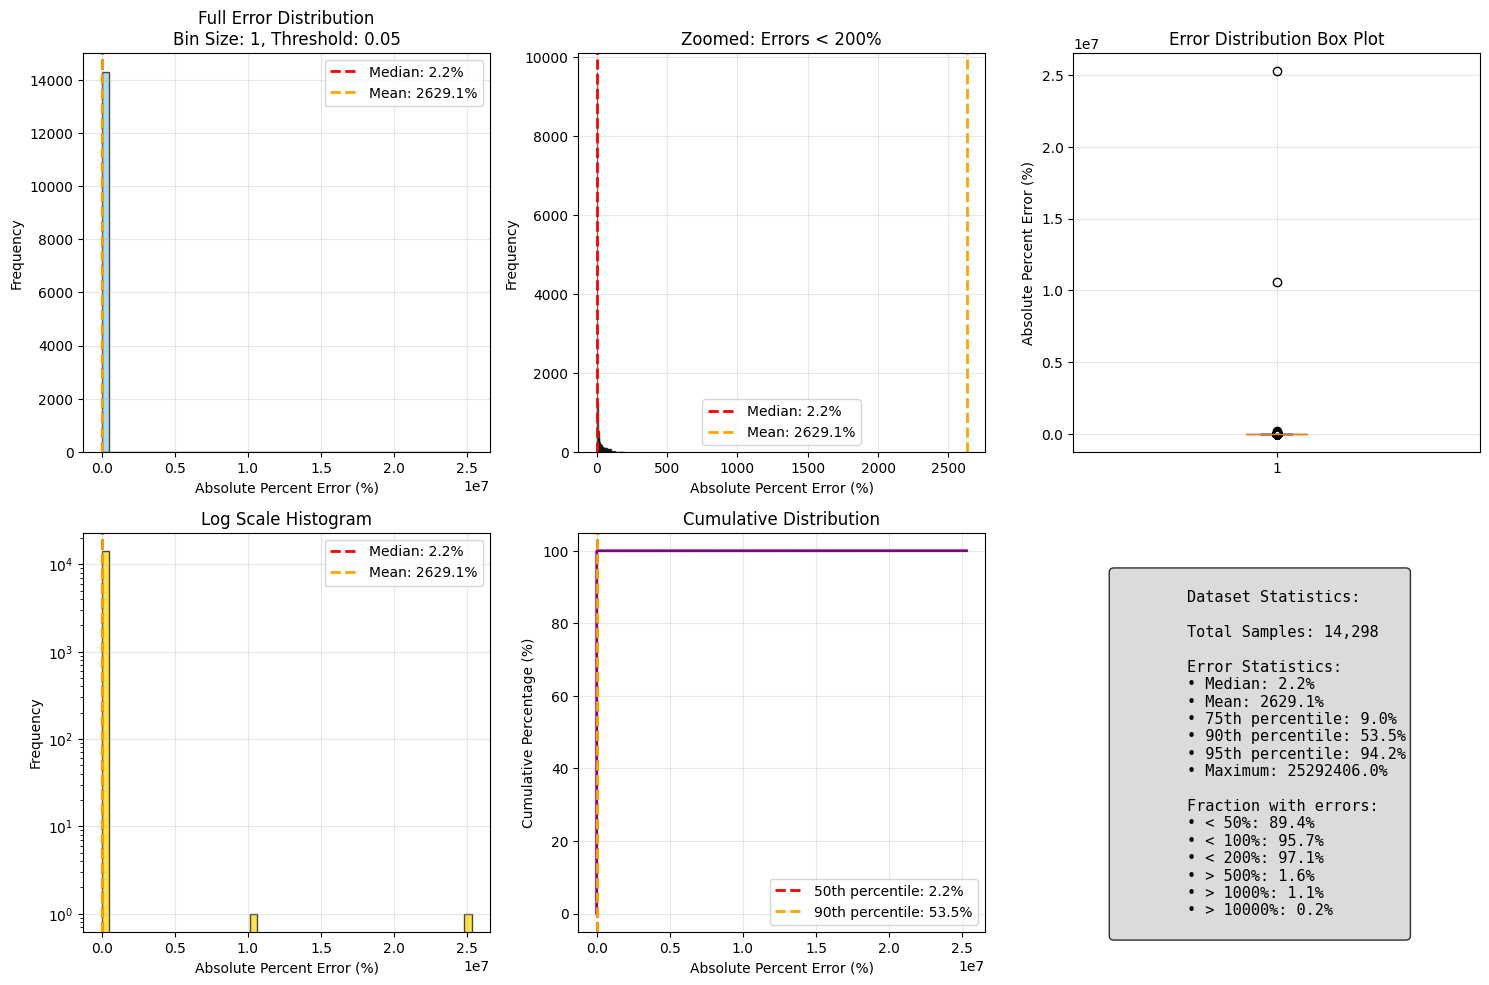


Outlier Analysis:
Number of outliers (>94.2%): 714 / 14298

Extreme Error Analysis:
Errors > 1000%: 152 / 14298 (1.06%)
Errors > 10000%: 27 / 14298 (0.19%)

Worst 20 predictions:
   1. True:    0.012, Pred: 3032.889, Error: 25292406.0%
   2. True:    0.012, Pred: 1266.040, Error: 10557929.1%
   3. True:    0.500, Pred: 1059.602, Error: 211820.5%
   4. True:    7.993, Pred: 8168.865, Error: 102097.8%
   5. True:    7.210, Pred: 6546.257, Error:  90694.1%
   6. True:    6.196, Pred: 4552.394, Error:  73372.4%
   7. True:    1.998, Pred: 1052.255, Error:  52554.7%
   8. True:    6.196, Pred: 3175.350, Error:  51147.9%
   9. True:    3.950, Pred: 2010.133, Error:  50789.4%
  10. True:    1.998, Pred:  995.312, Error:  49705.3%
  11. True:    6.995, Pred: 3076.346, Error:  43876.9%
  12. True:    6.995, Pred: 3076.346, Error:  43876.9%
  13. True:   49.963, Pred: 15848.797, Error:  31621.1%
  14. True:   18.000, Pred: 5490.722, Error:  30404.0%
  15. True:   18.000, Pred: 4757.678, Error: 

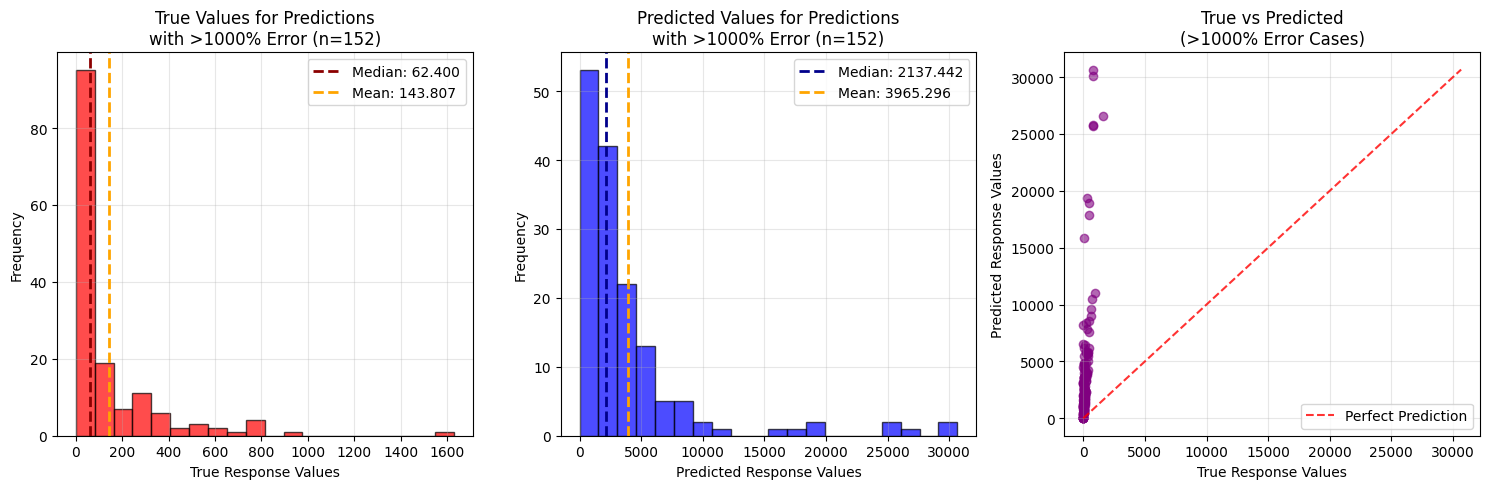


Statistics for predictions with >1000% error:
True values  - Min: 0.012, Max: 1628.738, Median: 62.400, Mean: 143.807
Pred values  - Min: 1.000, Max: 30659.797, Median: 2137.442, Mean: 3965.296

Value range analysis for >1000% errors:
True values < 1: 12 / 152 (7.9%)
True values > 100: 50 / 152 (32.9%)


In [15]:
def plot_error_distribution_for_dataset(bin_size, threshold, data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_outputs_df6"):
    """
    Generate a histogram showing the error distribution for a specific bin size and threshold.
    
    Parameters:
    -----------
    bin_size : float
        The bin size (e.g., 1, 5, 100, 1000)
    threshold : float  
        The threshold value (e.g., 0, 0.001, 0.1, 100)
    data_folder : str
        Path to the folder containing conditional encoder output files
    """
    
    # Convert bin_size and threshold to string format used in filenames
    if bin_size < 1:
        bin_str = f"bin{str(bin_size).replace('.', '_')}"
    else:
        bin_str = f"bin{int(bin_size)}"
    
    if threshold == 0:
        thresh_str = "thresh_zero"
    elif threshold < 1:
        thresh_str = f"thresh{str(threshold).replace('.', '_')}"
    else:
        thresh_str = f"thresh{int(threshold)}"
    
    # Construct filename
    dataset_name = f"cond_enc_{bin_str}_{thresh_str}_df_spectra"
    filename = f"{dataset_name}.parquet"
    file_path = os.path.join(data_folder, filename)
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"File not found: {filename}")
        print(f"Looking in: {data_folder}")
        return None
    
    try:
        # Load the data
        print(f"Loading data for bin_size={bin_size}, threshold={threshold}")
        df = pd.read_parquet(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:
            print(f"Too few valid samples: {len(y_pred_response_clean)}")
            return None
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate statistics
        median_error = np.median(individual_errors)
        mean_error = np.mean(individual_errors)
        q75_error = np.percentile(individual_errors, 75)
        q90_error = np.percentile(individual_errors, 90)
        q95_error = np.percentile(individual_errors, 95)
        max_error = np.max(individual_errors)
        
        # Create the histogram plot
        plt.figure(figsize=(15, 10))
        
        # Main histogram (full range)
        plt.subplot(2, 3, 1)
        plt.hist(individual_errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'Median: {median_error:.1f}%')
        plt.axvline(mean_error, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Frequency')
        plt.title(f'Full Error Distribution\nBin Size: {bin_size}, Threshold: {threshold}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Zoomed histogram (errors < 200%)
        plt.subplot(2, 3, 2)
        errors_zoomed = individual_errors[individual_errors < 200]
        plt.hist(errors_zoomed, bins=40, alpha=0.7, color='lightgreen', edgecolor='black')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'Median: {median_error:.1f}%')
        plt.axvline(mean_error, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Frequency')
        plt.title('Zoomed: Errors < 200%')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Box plot
        plt.subplot(2, 3, 3)
        plt.boxplot(individual_errors, patch_artist=True, 
                   boxprops=dict(facecolor='lightcoral', alpha=0.7))
        plt.ylabel('Absolute Percent Error (%)')
        plt.title('Error Distribution Box Plot')
        plt.grid(True, alpha=0.3)
        
        # Log scale histogram
        plt.subplot(2, 3, 4)
        plt.hist(individual_errors, bins=50, alpha=0.7, color='gold', edgecolor='black')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'Median: {median_error:.1f}%')
        plt.axvline(mean_error, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Frequency')
        plt.yscale('log')
        plt.title('Log Scale Histogram')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Cumulative distribution
        plt.subplot(2, 3, 5)
        sorted_errors = np.sort(individual_errors)
        cumulative_percent = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
        plt.plot(sorted_errors, cumulative_percent, linewidth=2, color='purple')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'50th percentile: {median_error:.1f}%')
        plt.axvline(q90_error, color='orange', linestyle='--', linewidth=2, label=f'90th percentile: {q90_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Cumulative Percentage (%)')
        plt.title('Cumulative Distribution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Statistics text
        plt.subplot(2, 3, 6)
        plt.axis('off')
        stats_text = f"""
        Dataset Statistics:
        
        Total Samples: {len(individual_errors):,}
        
        Error Statistics:
        • Median: {median_error:.1f}%
        • Mean: {mean_error:.1f}%
        • 75th percentile: {q75_error:.1f}%
        • 90th percentile: {q90_error:.1f}%
        • 95th percentile: {q95_error:.1f}%
        • Maximum: {max_error:.1f}%
        
        Fraction with errors:
        • < 50%: {(individual_errors < 50).mean()*100:.1f}%
        • < 100%: {(individual_errors < 100).mean()*100:.1f}%
        • < 200%: {(individual_errors < 200).mean()*100:.1f}%
        • > 500%: {(individual_errors > 500).mean()*100:.1f}%
        • > 1000%: {(individual_errors > 1000).mean()*100:.1f}%
        • > 10000%: {(individual_errors > 10000).mean()*100:.1f}%
        """
        plt.text(0.1, 0.9, stats_text, transform=plt.gca().transAxes, 
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Print outlier information
        print(f"\nOutlier Analysis:")
        outlier_threshold = q95_error
        outliers = individual_errors > outlier_threshold
        print(f"Number of outliers (>{outlier_threshold:.1f}%): {outliers.sum()} / {len(individual_errors)}")
        
        # Print extreme outlier statistics
        print(f"\nExtreme Error Analysis:")
        print(f"Errors > 1000%: {(individual_errors > 1000).sum()} / {len(individual_errors)} ({(individual_errors > 1000).mean()*100:.2f}%)")
        print(f"Errors > 10000%: {(individual_errors > 10000).sum()} / {len(individual_errors)} ({(individual_errors > 10000).mean()*100:.2f}%)")
        
        # Show worst 20 predictions (instead of just 5)
        if len(individual_errors) > 0:
            print(f"\nWorst 20 predictions:")
            worst_indices = np.argsort(individual_errors)[-20:][::-1]
            for i, idx in enumerate(worst_indices):
                print(f"  {i+1:2d}. True: {y_true_response_clean.iloc[idx]:8.3f}, "
                      f"Pred: {y_pred_response_clean.iloc[idx]:8.3f}, "
                      f"Error: {individual_errors[idx]:8.1f}%")
        
        # Create histogram of true values for predictions with >1000% error
        extreme_error_mask = individual_errors > 1000
        if extreme_error_mask.sum() > 0:
            print(f"\nAnalyzing true values for {extreme_error_mask.sum()} predictions with >1000% error...")
            
            extreme_true_values = y_true_response_clean[extreme_error_mask]
            extreme_pred_values = y_pred_response_clean[extreme_error_mask]
            
            plt.figure(figsize=(15, 5))
            
            # Histogram of true values for extreme errors
            plt.subplot(1, 3, 1)
            plt.hist(extreme_true_values, bins=20, alpha=0.7, color='red', edgecolor='black')
            plt.xlabel('True Response Values')
            plt.ylabel('Frequency')
            plt.title(f'True Values for Predictions\nwith >1000% Error (n={extreme_error_mask.sum()})')
            plt.grid(True, alpha=0.3)
            
            # Add statistics
            plt.axvline(np.median(extreme_true_values), color='darkred', linestyle='--', 
                       linewidth=2, label=f'Median: {np.median(extreme_true_values):.3f}')
            plt.axvline(np.mean(extreme_true_values), color='orange', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(extreme_true_values):.3f}')
            plt.legend()
            
            # Histogram of predicted values for extreme errors
            plt.subplot(1, 3, 2)
            plt.hist(extreme_pred_values, bins=20, alpha=0.7, color='blue', edgecolor='black')
            plt.xlabel('Predicted Response Values')
            plt.ylabel('Frequency')
            plt.title(f'Predicted Values for Predictions\nwith >1000% Error (n={extreme_error_mask.sum()})')
            plt.grid(True, alpha=0.3)
            
            # Add statistics
            plt.axvline(np.median(extreme_pred_values), color='darkblue', linestyle='--', 
                       linewidth=2, label=f'Median: {np.median(extreme_pred_values):.3f}')
            plt.axvline(np.mean(extreme_pred_values), color='orange', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(extreme_pred_values):.3f}')
            plt.legend()
            
            # Scatter plot: True vs Predicted for extreme errors
            plt.subplot(1, 3, 3)
            plt.scatter(extreme_true_values, extreme_pred_values, alpha=0.6, color='purple')
            plt.xlabel('True Response Values')
            plt.ylabel('Predicted Response Values')
            plt.title('True vs Predicted\n(>1000% Error Cases)')
            plt.grid(True, alpha=0.3)
            
            # Add diagonal line
            min_val = min(extreme_true_values.min(), extreme_pred_values.min())
            max_val = max(extreme_true_values.max(), extreme_pred_values.max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect Prediction')
            plt.legend()
            
            plt.tight_layout()
            plt.show()
            
            # Print statistics for extreme error cases
            print(f"\nStatistics for predictions with >1000% error:")
            print(f"True values  - Min: {extreme_true_values.min():.3f}, Max: {extreme_true_values.max():.3f}, "
                  f"Median: {np.median(extreme_true_values):.3f}, Mean: {np.mean(extreme_true_values):.3f}")
            print(f"Pred values  - Min: {extreme_pred_values.min():.3f}, Max: {extreme_pred_values.max():.3f}, "
                  f"Median: {np.median(extreme_pred_values):.3f}, Mean: {np.mean(extreme_pred_values):.3f}")
            
            # Check if extreme errors are associated with specific value ranges
            print(f"\nValue range analysis for >1000% errors:")
            print(f"True values < 1: {(extreme_true_values < 1).sum()} / {len(extreme_true_values)} ({(extreme_true_values < 1).mean()*100:.1f}%)")
            print(f"True values > 100: {(extreme_true_values > 100).sum()} / {len(extreme_true_values)} ({(extreme_true_values > 100).mean()*100:.1f}%)")
        else:
            print(f"\nNo predictions with >1000% error found.")
        
        return individual_errors
        
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        return None

# Plot error distribution 
errors = plot_error_distribution_for_dataset(bin_size=1, threshold=0.05)


In [26]:
def analyze_worst_predictions(bin_size=1, threshold=0.1, error_threshold=1000, toxicity_benchmark=50, 
                             data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_outputs_df6"):
    """
    Analyze worst predictions and proportion of low toxicity chemicals with high errors.
    
    Parameters:
    -----------
    bin_size : float
        The bin size (e.g., 1, 5, 100, 1000)
    threshold : float  
        The threshold value (e.g., 0, 0.001, 0.1, 100)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
        
    Returns:
    --------
    dict : Dictionary containing analysis results
    """
    
    # Convert bin_size and threshold to string format used in filenames
    if bin_size < 1:
        bin_str = f"bin{str(bin_size).replace('.', '_')}"
    else:
        bin_str = f"bin{int(bin_size)}"
    
    if threshold == 0:
        thresh_str = "thresh_zero"
    elif threshold < 1:
        thresh_str = f"thresh{str(threshold).replace('.', '_')}"
    else:
        thresh_str = f"thresh{int(threshold)}"
    
    # Construct filename
    dataset_name = f"cond_enc_{bin_str}_{thresh_str}_df_spectra"
    filename = f"{dataset_name}.parquet"
    file_path = os.path.join(data_folder, filename)
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"File not found: {filename}")
        return None
    
    try:
        # Load the data
        print(f"Loading data for bin_size={bin_size}, threshold={threshold}")
        df = pd.read_parquet(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:
            print(f"Too few valid samples: {len(y_pred_response_clean)}")
            return None
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # === WORST 20 PREDICTIONS TABLE ===
        print(f"\n{'='*80}")
        print(f"WORST 20 PREDICTIONS (Bin Size: {bin_size}, Threshold: {threshold})")
        print(f"{'='*80}")
        
        worst_indices = np.argsort(individual_errors)[::-1][:20]  # Get 20 worst, highest error first
        
        print(f"{'Rank':<4} {'True Value':<12} {'Predicted':<12} {'Error %':<12} {'SMILES':<30}")
        print(f"{'-'*80}")
        
        worst_predictions_data = []
        for i, idx in enumerate(worst_indices):
            true_val = y_true_response_clean.iloc[idx]
            pred_val = y_pred_response_clean.iloc[idx]
            error_pct = individual_errors[idx]
            smiles = df.iloc[idx]['SMILES_spectra'] if 'SMILES_spectra' in df.columns else 'N/A'
            smiles_short = smiles[:25] + "..." if len(smiles) > 25 else smiles
            
            print(f"{i+1:<4} {true_val:<12.3f} {pred_val:<12.3f} {error_pct:<12.1f} {smiles_short:<30}")
            
            worst_predictions_data.append({
                'rank': i+1,
                'true_value': true_val,
                'predicted_value': pred_val,
                'error_percent': error_pct,
                'smiles': smiles
            })
        
        # === PROPORTION ANALYSIS ===
        print(f"\n{'='*80}")
        print(f"PROPORTION ANALYSIS")
        print(f"{'='*80}")
        
        # Filter chemicals with true toxicity below benchmark
        low_toxicity_mask = y_true_response_clean < toxicity_benchmark
        low_toxicity_count = low_toxicity_mask.sum()
        
        # Among low toxicity chemicals, count those with high errors
        high_error_mask = individual_errors > error_threshold
        low_tox_high_error_mask = low_toxicity_mask & high_error_mask
        low_tox_high_error_count = low_tox_high_error_mask.sum()
        
        # Calculate proportion
        if low_toxicity_count > 0:
            proportion = low_tox_high_error_count / low_toxicity_count
        else:
            proportion = 0
        
        print(f"Toxicity benchmark: < {toxicity_benchmark}")
        print(f"Error threshold: > {error_threshold}%")
        print(f"")
        print(f"Total chemicals: {len(y_true_response_clean):,}")
        print(f"Chemicals with toxicity < {toxicity_benchmark}: {low_toxicity_count:,}")
        print(f"Chemicals with toxicity < {toxicity_benchmark} AND error > {error_threshold}%: {low_tox_high_error_count:,}")
        print(f"Proportion: {proportion:.3f} ({proportion*100:.1f}%)")
        
        # Additional breakdowns
        print(f"\nAdditional breakdowns:")
        print(f"• All chemicals with error > {error_threshold}%: {high_error_mask.sum():,} / {len(individual_errors):,} ({high_error_mask.mean()*100:.1f}%)")
        
        # Try different toxicity benchmarks
        benchmarks = [10, 25, 50, 100, 200]
        print(f"\nProportion analysis for different toxicity benchmarks:")
        print(f"{'Benchmark':<10} {'Count':<8} {'High Error':<12} {'Proportion':<12}")
        print(f"{'-'*45}")
        
        benchmark_results = []
        for bench in benchmarks:
            bench_mask = y_true_response_clean < bench
            bench_count = bench_mask.sum()
            bench_high_error = (bench_mask & high_error_mask).sum()
            bench_prop = bench_high_error / bench_count if bench_count > 0 else 0
            
            print(f"< {bench:<8} {bench_count:<8} {bench_high_error:<12} {bench_prop:<12.3f}")
            benchmark_results.append({
                'benchmark': bench,
                'count': bench_count,
                'high_error_count': bench_high_error,
                'proportion': bench_prop
            })
        
        return {
            'dataset_info': {
                'bin_size': bin_size,
                'threshold': threshold,
                'total_samples': len(y_true_response_clean)
            },
            'worst_predictions': worst_predictions_data,
            'proportion_analysis': {
                'toxicity_benchmark': toxicity_benchmark,
                'error_threshold': error_threshold,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'proportion': proportion,
                'benchmark_results': benchmark_results
            }
        }
        
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        return None

# Usage examples:

# Basic usage - easily changeable parameters
results = analyze_worst_predictions(
    bin_size=1,              
    threshold=0.05,            
    error_threshold=1000,    
    toxicity_benchmark=50    
)


Loading data for bin_size=1, threshold=0.05

WORST 20 PREDICTIONS (Bin Size: 1, Threshold: 0.05)
Rank True Value   Predicted    Error %      SMILES                        
--------------------------------------------------------------------------------
1    0.012        2121.265     17690000.2   CCC1CN2CCc3cc(OC)c(OC)cc3...  
2    0.012        390.556      3256910.4    CCC1CN2CCc3cc(OC)c(OC)cc3...  
3    0.500        1266.824     253264.9     CC1(C)O[C@@H]2C[C@H]3[C@@...  
4    7.210        9765.324     135341.4     COc1ccc2c(c1)c(CC(=O)O)c(...  
5    7.993        9930.389     124135.6     CCOP(=O)(NC(C)C)Oc1ccc(SC...  
6    6.196        5494.551     88578.2      O=C(NCc1cccnc1)Nc1ccc([N+...  
7    3.950        2747.946     69468.3      CC(=O)OC[C@]12C[C@H](OC(=...  
8    1.998        1312.060     65555.3      CCOP(=S)(OCC)Oc1ccc([N+](...  
9    6.196        3998.991     64440.9      O=C(NCc1cccnc1)Nc1ccc([N+...  
10   1.998        1196.695     59782.4      CCOP(=S)(OCC)Oc1ccc([N+](...

Analyzing proportion for threshold=0.05, error_threshold=100%, toxicity_benchmark=50
Processing bin sizes...
  Bin 0.5: 0.296 (29.6%) - 146/493 low tox with high error
  Bin 1: 0.282 (28.2%) - 139/493 low tox with high error
  Bin 2: 0.331 (33.1%) - 163/493 low tox with high error
  Bin 5: 0.383 (38.3%) - 189/493 low tox with high error


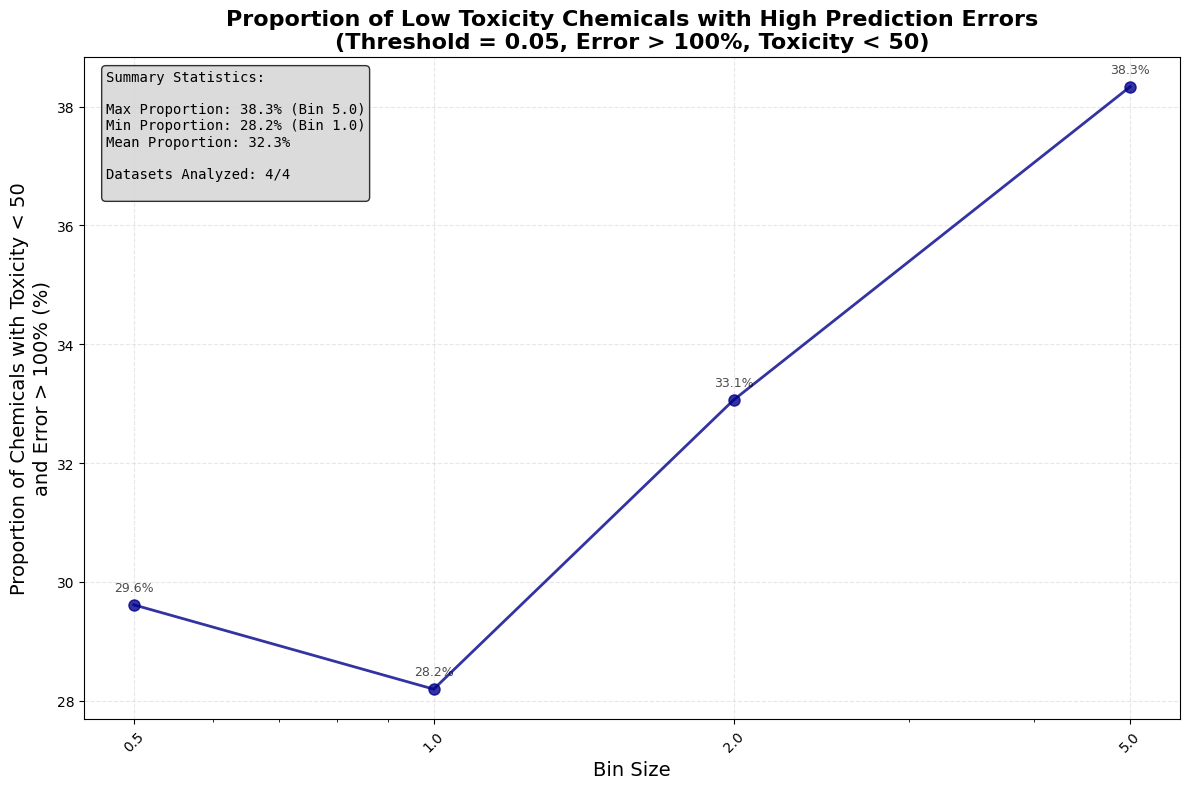


DETAILED RESULTS TABLE
Bin Size   Proportion   Low Tox Count   High Error Count   Total Samples  
--------------------------------------------------------------------------------
0.5        0.296        493.0           146.0              14298.0        
1.0        0.282        493.0           139.0              14298.0        
2.0        0.331        493.0           163.0              14298.0        
5.0        0.383        493.0           189.0              14298.0        


In [27]:
def plot_proportion_by_bin_size(threshold=1, error_threshold=1000, toxicity_benchmark=50, 
                               data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_outputs_df6",
                               figsize=(12, 8)):
    """
    Create a line plot showing the proportion of low toxicity chemicals with high errors across bin sizes.
    
    Parameters:
    -----------
    threshold : float
        The threshold value to use for all datasets (default: 1)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
    figsize : tuple
        Figure size for the plot (default: (12, 8))
    """
    
    # Define bin sizes to analyze
    bin_sizes =  [0.5, 1, 2, 5] #[0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
    # bin_sizes =  [0.5, 1, 10, 25, 100, 200, 1000]
    # Storage for results
    results = []
    
    print(f"Analyzing proportion for threshold={threshold}, error_threshold={error_threshold}%, toxicity_benchmark={toxicity_benchmark}")
    print("Processing bin sizes...")
    
    for bin_size in bin_sizes:
        # Convert bin_size and threshold to string format used in filenames
        if bin_size < 1:
            bin_str = f"bin{str(bin_size).replace('.', '_')}"
        else:
            bin_str = f"bin{int(bin_size)}"
        
        if threshold == 0:
            thresh_str = "thresh_zero"
        elif threshold < 1:
            thresh_str = f"thresh{str(threshold).replace('.', '_')}"
        else:
            thresh_str = f"thresh{int(threshold)}"
        
        # Construct filename
        dataset_name = f"cond_enc_{bin_str}_{thresh_str}_df_spectra"
        filename = f"{dataset_name}.parquet"
        file_path = os.path.join(data_folder, filename)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"  Bin {bin_size}: File not found")
            continue
        
        try:
            # Load the data
            df = pd.read_parquet(file_path)
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']
            y_true_response = df['Response']
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:
                print(f"  Bin {bin_size}: Too few samples ({len(y_pred_response_clean)})")
                continue
            
            # Calculate absolute percent error
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate proportion
            low_toxicity_mask = y_true_response_clean < toxicity_benchmark
            high_error_mask = individual_errors > error_threshold
            low_tox_high_error_mask = low_toxicity_mask & high_error_mask
            
            low_toxicity_count = low_toxicity_mask.sum()
            low_tox_high_error_count = low_tox_high_error_mask.sum()
            
            if low_toxicity_count > 0:
                proportion = low_tox_high_error_count / low_toxicity_count
            else:
                proportion = 0
            
            results.append({
                'bin_size': bin_size,
                'proportion': proportion,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'total_samples': len(y_pred_response_clean)
            })
            
            print(f"  Bin {bin_size}: {proportion:.3f} ({proportion*100:.1f}%) - {low_tox_high_error_count}/{low_toxicity_count} low tox with high error")
            
        except Exception as e:
            print(f"  Bin {bin_size}: Error - {str(e)}")
            continue
    
    if not results:
        print("No valid data found for any bin size!")
        return None
    
    # Convert to DataFrame for easier plotting
    df_results = pd.DataFrame(results)
    
    # Create the line plot
    plt.figure(figsize=figsize)
    
    # Main line plot
    plt.plot(df_results['bin_size'], df_results['proportion'] * 100, 
             marker='o', linewidth=2, markersize=8, color='darkblue', alpha=0.8)
    
    # Add data points with values
    for _, row in df_results.iterrows():
        plt.annotate(f'{row["proportion"]*100:.1f}%', 
                    (row['bin_size'], row['proportion']*100),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, alpha=0.7)
    
    # Formatting
    plt.xlabel('Bin Size', fontsize=14)
    plt.ylabel(f'Proportion of Chemicals with Toxicity < {toxicity_benchmark}\nand Error > {error_threshold}% (%)', fontsize=14)
    plt.title(f'Proportion of Low Toxicity Chemicals with High Prediction Errors\n(Threshold = {threshold}, Error > {error_threshold}%, Toxicity < {toxicity_benchmark})', 
              fontsize=16, fontweight='bold')
    
    # Set x-axis to log scale for better visibility
    plt.xscale('log')
    plt.xticks(df_results['bin_size'], [str(x) for x in df_results['bin_size']], rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add summary statistics as text box
    max_prop = df_results['proportion'].max()
    min_prop = df_results['proportion'].min()
    max_bin = df_results.loc[df_results['proportion'].idxmax(), 'bin_size']
    min_bin = df_results.loc[df_results['proportion'].idxmin(), 'bin_size']
    
    stats_text = f"""Summary Statistics:
    
Max Proportion: {max_prop*100:.1f}% (Bin {max_bin})
Min Proportion: {min_prop*100:.1f}% (Bin {min_bin})
Mean Proportion: {df_results['proportion'].mean()*100:.1f}%

Datasets Analyzed: {len(df_results)}/{len(bin_sizes)}
    """
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS TABLE")
    print(f"{'='*80}")
    print(f"{'Bin Size':<10} {'Proportion':<12} {'Low Tox Count':<15} {'High Error Count':<18} {'Total Samples':<15}")
    print(f"{'-'*80}")
    
    for _, row in df_results.iterrows():
        print(f"{row['bin_size']:<10} {row['proportion']:<12.3f} {row['low_toxicity_count']:<15} {row['low_tox_high_error_count']:<18} {row['total_samples']:<15}")
    
    return df_results

# Usage examples with easily changeable parameters:

# Default parameters
results = plot_proportion_by_bin_size(
    threshold=0.05,              
    error_threshold=100,       
    toxicity_benchmark=50     
)


# 1234e1e2 Weighted Regular Test Heatmap

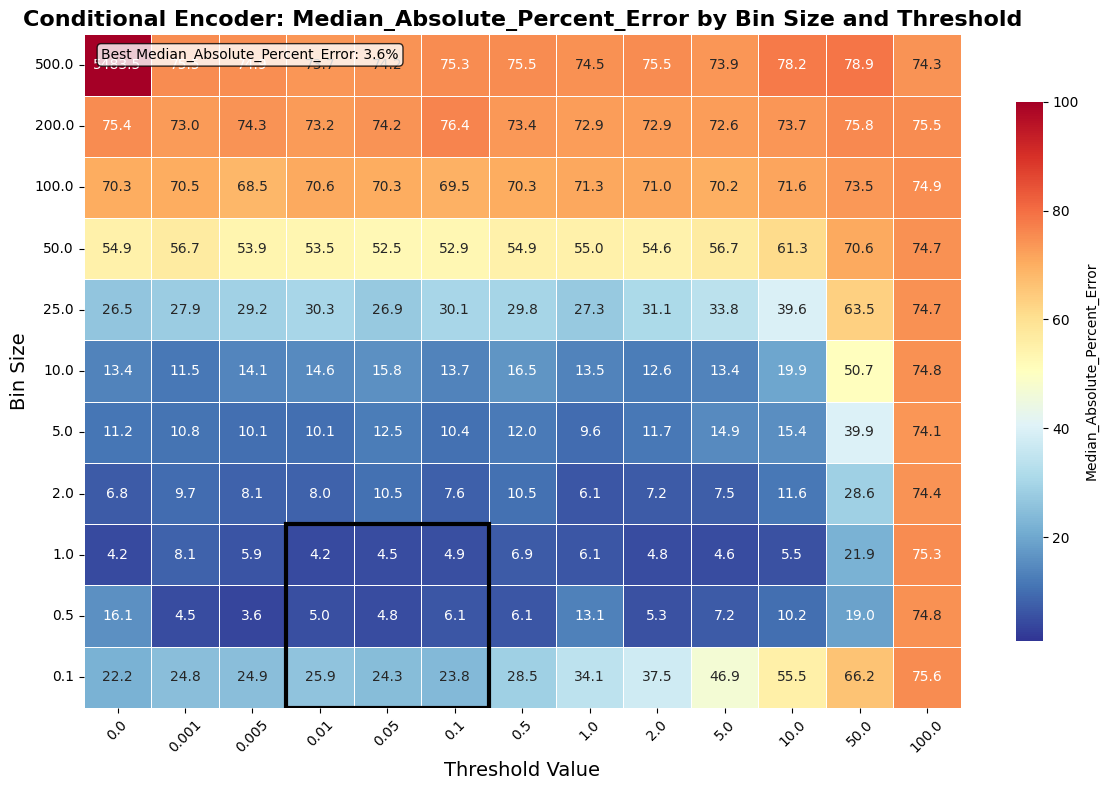

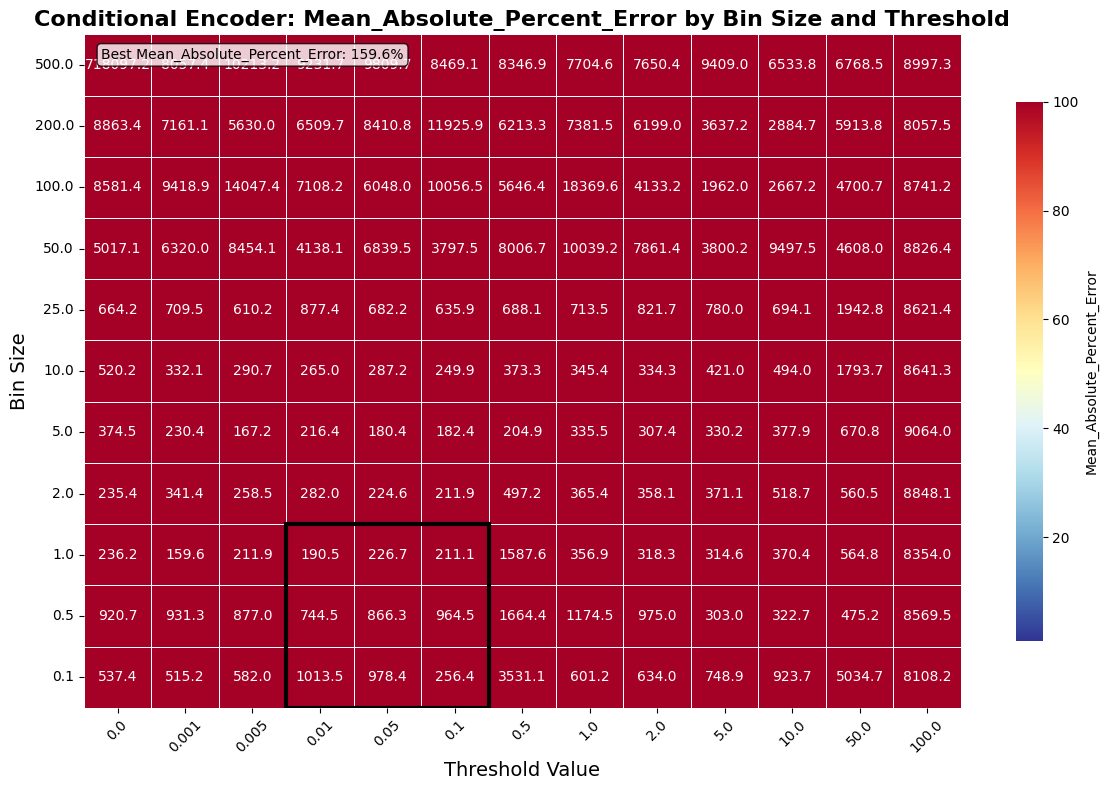

In [11]:
# Small Heatmap
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle 

# Load conditional encoder datasets folder path
cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_outputs_df6"

# Get all .parquet files in the folder
cond_enc_parquet_files = [f for f in os.listdir(cond_enc_folder) if f.endswith('.parquet')]
cond_enc_dataset_names = [f.replace('.parquet', '') for f in cond_enc_parquet_files]

# Initialize storage for conditional encoder results (percent error only)
cond_enc_results_percent_error = []

# Process conditional encoder datasets
for i, dataset_name in enumerate(sorted(cond_enc_dataset_names), 1):
    try:
        # Load the conditional encoder dataset
        file_path = os.path.join(cond_enc_folder, f"{dataset_name}.parquet")
        df = pd.read_parquet(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:  # Skip if too few samples
            continue
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate median and mean absolute percent error
        median_percent_error = np.median(individual_errors)
        mean_percent_error = np.mean(individual_errors)
        
        # Store results
        cond_enc_results_percent_error.append({
            'Dataset': dataset_name,
            'Median_Percent_Error': median_percent_error,
            'Mean_Percent_Error': mean_percent_error,
            'Samples': len(y_pred_response_clean)
        })
        
    except Exception as e:
        continue

# Convert results to DataFrame
df_cond_enc_percent_error_results = pd.DataFrame(cond_enc_results_percent_error)

# Function to parse conditional encoder dataset names
def parse_cond_enc_dataset_name(dataset_name):
    """Extract bin size and threshold from full conditional encoder dataset name"""
    # Remove 'cond_enc_full2_' prefix
    name_part = dataset_name.replace('cond_enc_', '') 
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns
bin_sizes = []
thresholds = []

for dataset_name in df_cond_enc_percent_error_results['Dataset']:
    bin_size, threshold = parse_cond_enc_dataset_name(dataset_name)
    bin_sizes.append(bin_size)
    thresholds.append(threshold)

df_cond_enc_percent_error_results['BinSize'] = bin_sizes
df_cond_enc_percent_error_results['Threshold'] = thresholds

# Remove duplicates
df_cond_enc_percent_error_results = df_cond_enc_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

# Create pivot tables
cond_enc_median_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Median_Percent_Error')
cond_enc_mean_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Mean_Percent_Error')

# # List all expected thresholds and bin sizes
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]
# # List all expected thresholds and bin sizes
# bins_subset = [0.5, 1, 2] # 0.5,
# thresholds_subset = [0.01, 0.05, 0.1] #  0.05,

# Reindex pivot tables
cond_enc_median_percent_error_pivot = cond_enc_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
cond_enc_mean_percent_error_pivot = cond_enc_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Function to create heatmaps with highlighting
def create_detailed_heatmap_cond_enc(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single Conditional Encoder metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    ax = sns.heatmap(pivot_data, 
                     annot=True, 
                     fmt='.1f', 
                     cmap=cmap,
                     square=False,
                     linewidths=0.5,
                     vmin=vmin,
                     vmax=vmax,
                     cbar_kws={'label': f'{metric_name}', 'shrink': 0.8})
    
    # Find indices for the target bins and thresholds
    target_bins = [0.5, 1, 2]
    target_thresholds = [0.01, 0.05, 0.1]
    
    # Get the row and column indices for highlighting
    row_indices = []
    for bin_val in target_bins:
        if bin_val in pivot_data.index:
            row_indices.append(pivot_data.index.get_loc(bin_val))
    
    col_indices = []
    for thresh_val in target_thresholds:
        if thresh_val in pivot_data.columns:
            col_indices.append(pivot_data.columns.get_loc(thresh_val))
    
    # Create a single rectangle around the entire region
    if row_indices and col_indices:
        min_row = min(row_indices)
        max_row = max(row_indices)
        min_col = min(col_indices)
        max_col = max(col_indices)
        
        # Calculate width and height of the region
        width = max_col - min_col + 1
        height = 3
        
        # Add single rectangle around the entire region
        rect = Rectangle((min_col, 0), width, height, 
                       linewidth=3, 
                       edgecolor='black', 
                       facecolor='none')
        ax.add_patch(rect)
    
    plt.title(f'Conditional Encoder: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_val = pivot_data.min().min()
    plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    # plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/CondEnc_{metric_name}_by_Bin_Size_and_Threshold.png", 
    #             dpi=300, bbox_inches='tight')
    plt.show()

# Create heatmaps
create_detailed_heatmap_cond_enc(cond_enc_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_cond_enc(cond_enc_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

In [12]:
import os
import glob

# Define the directory path
folder_path = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_supertest_outputs"

# Find and delete all files with "_filtered" in their name
filtered_files = glob.glob(os.path.join(folder_path, "*_filtered*"))

print(f"Deleting {len(filtered_files)} files with '_filtered' in their name...")

deleted_count = 0
for file_path in filtered_files:
    try:
        os.remove(file_path)
        deleted_count += 1
    except Exception as e:
        print(f"Failed to delete {os.path.basename(file_path)}: {e}")

print(f"Successfully deleted {deleted_count} files.")

Deleting 0 files with '_filtered' in their name...
Successfully deleted 0 files.


# 1234e1e2 Weighted Super Test Heatmap

In [ ]:
# Small Heatmap
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle 

# Load conditional encoder datasets folder path
cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_supertest_outputs"

# Get all .parquet files in the folder
cond_enc_parquet_files = [f for f in os.listdir(cond_enc_folder) if f.endswith('.parquet')]
cond_enc_dataset_names = [f.replace('.parquet', '') for f in cond_enc_parquet_files]

# Initialize storage for conditional encoder results (percent error only)
cond_enc_results_percent_error = []

# Process conditional encoder datasets
for i, dataset_name in enumerate(sorted(cond_enc_dataset_names), 1):
    try:
        # Load the conditional encoder dataset
        file_path = os.path.join(cond_enc_folder, f"{dataset_name}.parquet")
        df = pd.read_parquet(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:  # Skip if too few samples
            continue
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate median and mean absolute percent error
        median_percent_error = np.median(individual_errors)
        mean_percent_error = np.mean(individual_errors)
        
        # Store results
        cond_enc_results_percent_error.append({
            'Dataset': dataset_name,
            'Median_Percent_Error': median_percent_error,
            'Mean_Percent_Error': mean_percent_error,
            'Samples': len(y_pred_response_clean)
        })
        
    except Exception as e:
        continue

# Convert results to DataFrame
df_cond_enc_percent_error_results = pd.DataFrame(cond_enc_results_percent_error)

# Function to parse conditional encoder dataset names
def parse_cond_enc_dataset_name(dataset_name):
    """Extract bin size and threshold from full conditional encoder dataset name"""
    # Remove 'cond_enc_full2_' prefix
    name_part = dataset_name.replace('super_test_cond_enc_', '') 
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns
bin_sizes = []
thresholds = []

for dataset_name in df_cond_enc_percent_error_results['Dataset']:
    bin_size, threshold = parse_cond_enc_dataset_name(dataset_name)
    bin_sizes.append(bin_size)
    thresholds.append(threshold)

df_cond_enc_percent_error_results['BinSize'] = bin_sizes
df_cond_enc_percent_error_results['Threshold'] = thresholds

# Remove duplicates
df_cond_enc_percent_error_results = df_cond_enc_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

# Create pivot tables
cond_enc_median_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Median_Percent_Error')
cond_enc_mean_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Mean_Percent_Error')

# # List all expected thresholds and bin sizes
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]

# List all expected thresholds and bin sizes
# bins_subset = [0.5, 1, 2] # 0.5,
# thresholds_subset = [0.01, 0.05, 0.1] #  0.05,

# Reindex pivot tables
cond_enc_median_percent_error_pivot = cond_enc_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
cond_enc_mean_percent_error_pivot = cond_enc_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Function to create heatmaps with highlighting
def create_detailed_heatmap_cond_enc(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single Conditional Encoder metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    ax = sns.heatmap(pivot_data, 
                     annot=True, 
                     fmt='.1f', 
                     cmap=cmap,
                     square=False,
                     linewidths=0.5,
                     vmin=vmin,
                     vmax=vmax,
                     cbar_kws={'label': f'{metric_name}', 'shrink': 0.8})
    
    # Find indices for the target bins and thresholds
    target_bins = [0.5, 1, 2]
    target_thresholds = [0.01, 0.05, 0.1]
    
    # Get the row and column indices for highlighting
    row_indices = []
    for bin_val in target_bins:
        if bin_val in pivot_data.index:
            row_indices.append(pivot_data.index.get_loc(bin_val))
    
    col_indices = []
    for thresh_val in target_thresholds:
        if thresh_val in pivot_data.columns:
            col_indices.append(pivot_data.columns.get_loc(thresh_val))
    
    # Create a single rectangle around the entire region
    if row_indices and col_indices:
        min_row = min(row_indices)
        max_row = max(row_indices)
        min_col = min(col_indices)
        max_col = max(col_indices)
        
        # Calculate width and height of the region
        width = 3
        height = 3
        
        # Add single rectangle around the entire region
        rect = Rectangle((min_col, 0), width, height, 
                       linewidth=3, 
                       edgecolor='black', 
                       facecolor='none')
        ax.add_patch(rect)
    
    plt.title(f'Conditional Encoder: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_val = pivot_data.min().min()
    plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    # plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/CondEnc_{metric_name}_by_Bin_Size_and_Threshold.png", 
    #             dpi=300, bbox_inches='tight')
    plt.show()

# Create heatmaps
create_detailed_heatmap_cond_enc(cond_enc_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_cond_enc(cond_enc_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

KeyboardInterrupt: 

# Proportion Comparisions Regular Test Set

Analyzing proportion for threshold=0.05, error_threshold=1000%, toxicity_benchmark=50
Processing bin sizes...
  Bin 0.5: 0.129 (12.9%) - 94/731 low tox with high error
  Bin 1: 0.148 (14.8%) - 108/731 low tox with high error
  Bin 2: 0.174 (17.4%) - 127/731 low tox with high error
  Bin 5: 0.197 (19.7%) - 144/731 low tox with high error


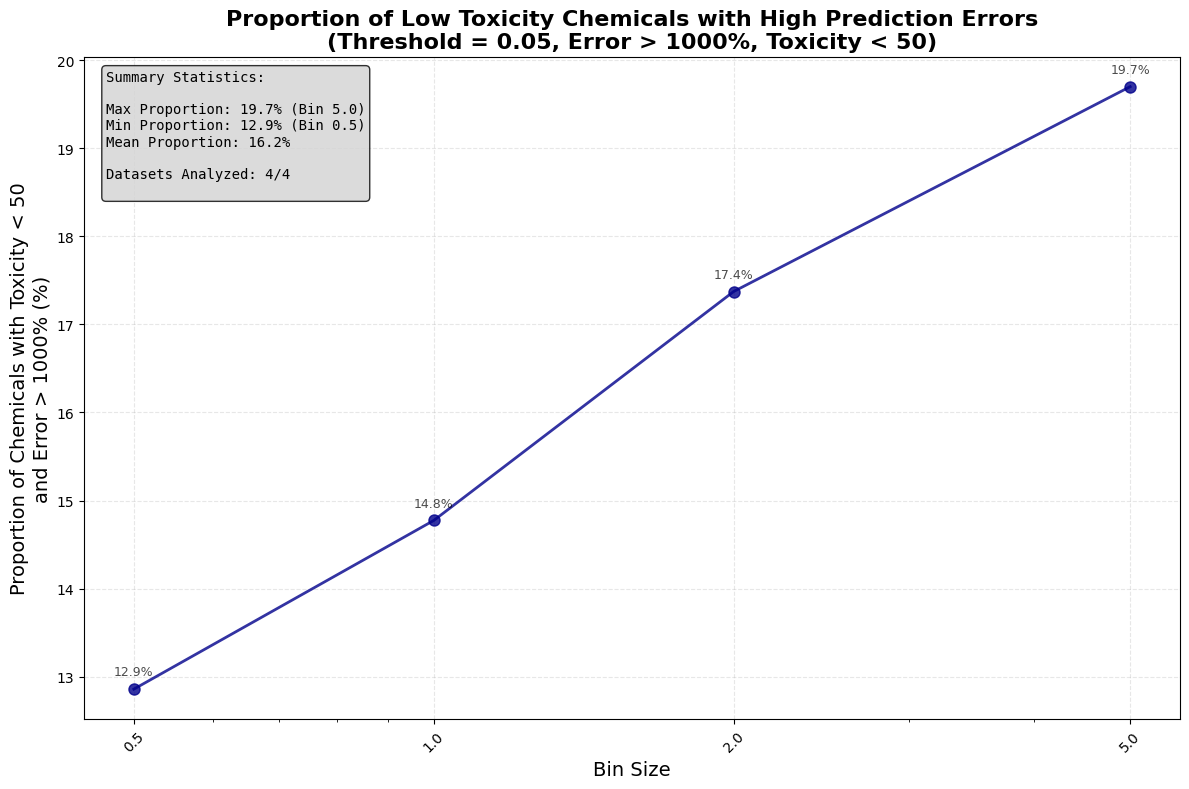


DETAILED RESULTS TABLE
Bin Size   Proportion   Low Tox Count   High Error Count   Total Samples  
--------------------------------------------------------------------------------
0.5        0.129        731.0           94.0               14697.0        
1.0        0.148        731.0           108.0              14697.0        
2.0        0.174        731.0           127.0              14697.0        
5.0        0.197        731.0           144.0              14697.0        

MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE
Bin Size   Mean Error %    Median Error % 
------------------------------------------------------------
0.5        866.3           4.8            
1.0        226.7           4.5            
2.0        224.6           10.5           
5.0        180.4           12.5           


In [24]:
# PROPORTIONS WITH FILTERED MF BUT NO WEIGHTING

def plot_proportion_by_bin_size(threshold=1, error_threshold=1000, toxicity_benchmark=50, 
                               data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_outputs_df6",
                               figsize=(12, 8)):
    """
    Create a line plot showing the proportion of low toxicity chemicals with high errors across bin sizes.
    
    Parameters:
    -----------
    threshold : float
        The threshold value to use for all datasets (default: 1)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
    figsize : tuple
        Figure size for the plot (default: (12, 8))
    """
    
    # Define bin sizes to analyze
    bin_sizes =  [0.5, 1, 2, 5] #[0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
    # bin_sizes =  [0.5, 1, 10, 25, 100, 200, 1000]
    # Storage for results
    results = []
    
    print(f"Analyzing proportion for threshold={threshold}, error_threshold={error_threshold}%, toxicity_benchmark={toxicity_benchmark}")
    print("Processing bin sizes...")
    
    for bin_size in bin_sizes:
        # Convert bin_size and threshold to string format used in filenames
        if bin_size < 1:
            bin_str = f"bin{str(bin_size).replace('.', '_')}"
        else:
            bin_str = f"bin{int(bin_size)}"
        
        if threshold == 0:
            thresh_str = "thresh_zero"
        elif threshold < 1:
            thresh_str = f"thresh{str(threshold).replace('.', '_')}"
        else:
            thresh_str = f"thresh{int(threshold)}"
        
        # Construct filename
        dataset_name = f"cond_enc_{bin_str}_{thresh_str}_df_spectra"
        filename = f"{dataset_name}.parquet"
        file_path = os.path.join(data_folder, filename)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"  Bin {bin_size}: File not found")
            continue
        
        try:
            # Load the data
            df = pd.read_parquet(file_path)
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']
            y_true_response = df['Response']
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)
            
            # # Convert from reciprocal back to log scale, then to original scale
            # y_pred_log_actual = 1.0 / y_pred_log
            # y_pred_response = np.exp(y_pred_log_actual)

            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:
                print(f"  Bin {bin_size}: Too few samples ({len(y_pred_response_clean)})")
                continue
            
            # Calculate absolute percent error
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate proportion
            low_toxicity_mask = y_true_response_clean < toxicity_benchmark
            high_error_mask = individual_errors > error_threshold
            low_tox_high_error_mask = low_toxicity_mask & high_error_mask
            
            low_toxicity_count = low_toxicity_mask.sum()
            low_tox_high_error_count = low_tox_high_error_mask.sum()
            
            if low_toxicity_count > 0:
                proportion = low_tox_high_error_count / low_toxicity_count
            else:
                proportion = 0
            
            results.append({
                'bin_size': bin_size,
                'proportion': proportion,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'total_samples': len(y_pred_response_clean),
                'mean_error': individual_errors.mean(),
                'median_error': individual_errors.median()
            })
            
            print(f"  Bin {bin_size}: {proportion:.3f} ({proportion*100:.1f}%) - {low_tox_high_error_count}/{low_toxicity_count} low tox with high error")
            
        except Exception as e:
            print(f"  Bin {bin_size}: Error - {str(e)}")
            continue
    
    if not results:
        print("No valid data found for any bin size!")
        return None
    
    # Convert to DataFrame for easier plotting
    df_results = pd.DataFrame(results)
    
    # Create the line plot
    plt.figure(figsize=figsize)
    
    # Main line plot
    plt.plot(df_results['bin_size'], df_results['proportion'] * 100, 
             marker='o', linewidth=2, markersize=8, color='darkblue', alpha=0.8)
    
    # Add data points with values
    for _, row in df_results.iterrows():
        plt.annotate(f'{row["proportion"]*100:.1f}%', 
                    (row['bin_size'], row['proportion']*100),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, alpha=0.7)
    
    # Formatting
    plt.xlabel('Bin Size', fontsize=14)
    plt.ylabel(f'Proportion of Chemicals with Toxicity < {toxicity_benchmark}\nand Error > {error_threshold}% (%)', fontsize=14)
    plt.title(f'Proportion of Low Toxicity Chemicals with High Prediction Errors\n(Threshold = {threshold}, Error > {error_threshold}%, Toxicity < {toxicity_benchmark})', 
              fontsize=16, fontweight='bold')
    
    # Set x-axis to log scale for better visibility
    plt.xscale('log')
    plt.xticks(df_results['bin_size'], [str(x) for x in df_results['bin_size']], rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add summary statistics as text box
    max_prop = df_results['proportion'].max()
    min_prop = df_results['proportion'].min()
    max_bin = df_results.loc[df_results['proportion'].idxmax(), 'bin_size']
    min_bin = df_results.loc[df_results['proportion'].idxmin(), 'bin_size']
    
    stats_text = f"""Summary Statistics:
    
Max Proportion: {max_prop*100:.1f}% (Bin {max_bin})
Min Proportion: {min_prop*100:.1f}% (Bin {min_bin})
Mean Proportion: {df_results['proportion'].mean()*100:.1f}%

Datasets Analyzed: {len(df_results)}/{len(bin_sizes)}
    """
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS TABLE")
    print(f"{'='*80}")
    print(f"{'Bin Size':<10} {'Proportion':<12} {'Low Tox Count':<15} {'High Error Count':<18} {'Total Samples':<15}")
    print(f"{'-'*80}")
    
    for _, row in df_results.iterrows():
        print(f"{row['bin_size']:<10} {row['proportion']:<12.3f} {row['low_toxicity_count']:<15} {row['low_tox_high_error_count']:<18} {row['total_samples']:<15}")
    
    return df_results

# Usage examples with easily changeable parameters:

# Default parameters
results = plot_proportion_by_bin_size(
    threshold=0.05,              
    error_threshold=1000,       
    toxicity_benchmark=50     
)

# Print mean and median percent error table
if results is not None:
    print(f"\n{'='*60}")
    print(f"MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE")
    print(f"{'='*60}")
    print(f"{'Bin Size':<10} {'Mean Error %':<15} {'Median Error %':<15}")
    print(f"{'-'*60}")
    
    for _, row in results.iterrows():
        print(f"{row['bin_size']:<10} {row['mean_error']:<15.1f} {row['median_error']:<15.1f}")

Analyzing proportion for threshold=0.05, error_threshold=1000%, toxicity_benchmark=50
Processing bin sizes...


  Bin 0.5: 0.140 (14.0%) - 102/731 low tox with high error
  Bin 1: 0.145 (14.5%) - 106/731 low tox with high error
  Bin 2: 0.164 (16.4%) - 120/731 low tox with high error
  Bin 5: 0.216 (21.6%) - 158/731 low tox with high error


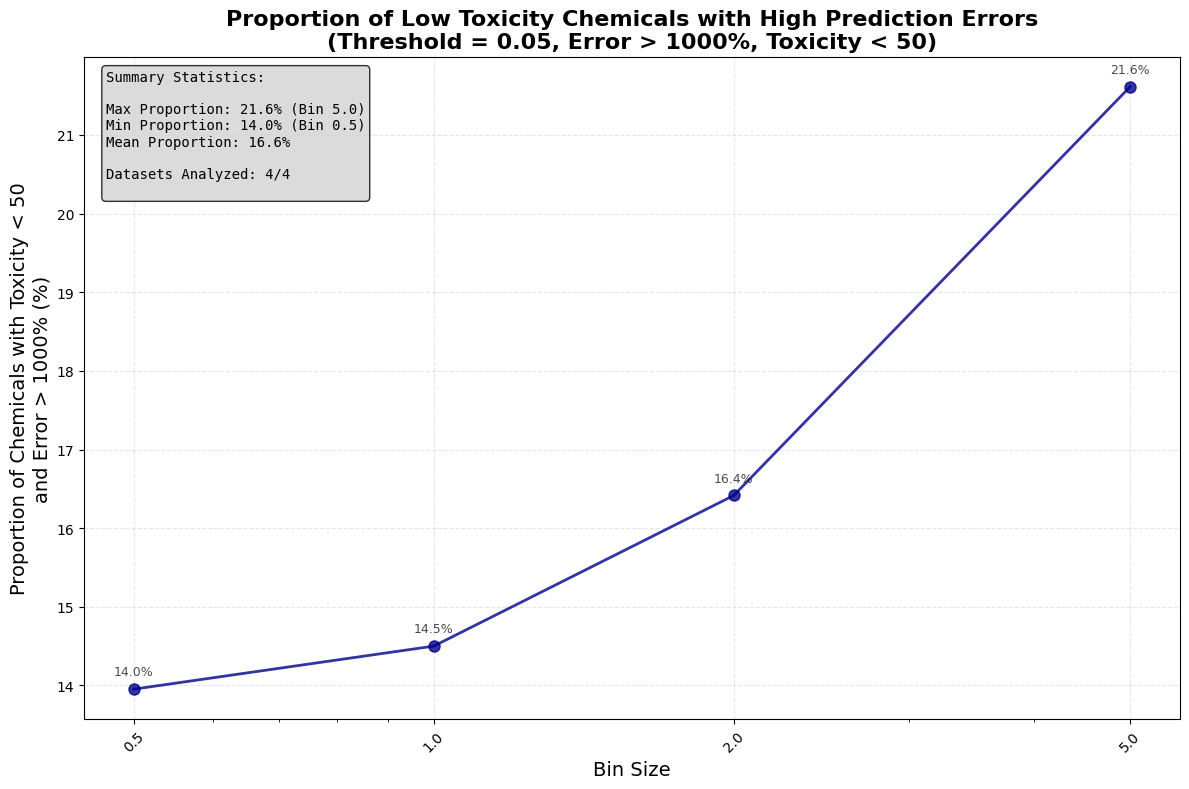


DETAILED RESULTS TABLE
Bin Size   Proportion   Low Tox Count   High Error Count   Total Samples  
--------------------------------------------------------------------------------
0.5        0.140        731.0           102.0              14697.0        
1.0        0.145        731.0           106.0              14697.0        
2.0        0.164        731.0           120.0              14697.0        
5.0        0.216        731.0           158.0              14697.0        

MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE
Bin Size   Mean Error %    Median Error % 
------------------------------------------------------------
0.5        949.4           5.1            
1.0        200.1           4.5            
2.0        201.9           12.8           
5.0        354.6           11.5           


In [25]:
# PROPORTIONS WITH NO FILTERED MF AND WEIGHTING


def plot_proportion_by_bin_size(threshold=1, error_threshold=1000, toxicity_benchmark=50, 
                               data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/temp_test_nofilt",
                               figsize=(12, 8)):
    """
    Create a line plot showing the proportion of low toxicity chemicals with high errors across bin sizes.
    
    Parameters:
    -----------
    threshold : float
        The threshold value to use for all datasets (default: 1)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
    figsize : tuple
        Figure size for the plot (default: (12, 8))
    """
    
    # Define bin sizes to analyze
    bin_sizes =  [0.5, 1, 2, 5] #[0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
    # bin_sizes =  [0.5, 1, 10, 25, 100, 200, 1000]
    # Storage for results
    results = []
    
    print(f"Analyzing proportion for threshold={threshold}, error_threshold={error_threshold}%, toxicity_benchmark={toxicity_benchmark}")
    print("Processing bin sizes...")
    
    for bin_size in bin_sizes:
        # Convert bin_size and threshold to string format used in filenames
        if bin_size < 1:
            bin_str = f"bin{str(bin_size).replace('.', '_')}"
        else:
            bin_str = f"bin{int(bin_size)}"
        
        if threshold == 0:
            thresh_str = "thresh_zero"
        elif threshold < 1:
            thresh_str = f"thresh{str(threshold).replace('.', '_')}"
        else:
            thresh_str = f"thresh{int(threshold)}"
        
        # Construct filename
        dataset_name = f"cond_enc_{bin_str}_{thresh_str}_df_spectra"
        filename = f"{dataset_name}.parquet"
        file_path = os.path.join(data_folder, filename)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"  Bin {bin_size}: File not found")
            continue
        
        try:
            # Load the data
            df = pd.read_parquet(file_path)
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']
            y_true_response = df['Response']
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)

            # # Convert from reciprocal back to log scale, then to original scale
            # y_pred_log_actual = 1.0 / y_pred_log
            # y_pred_response = np.exp(y_pred_log_actual)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:
                print(f"  Bin {bin_size}: Too few samples ({len(y_pred_response_clean)})")
                continue
            
            # Calculate absolute percent error
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate proportion
            low_toxicity_mask = y_true_response_clean < toxicity_benchmark
            high_error_mask = individual_errors > error_threshold
            low_tox_high_error_mask = low_toxicity_mask & high_error_mask
            
            low_toxicity_count = low_toxicity_mask.sum()
            low_tox_high_error_count = low_tox_high_error_mask.sum()
            
            if low_toxicity_count > 0:
                proportion = low_tox_high_error_count / low_toxicity_count
            else:
                proportion = 0
            
            results.append({
                'bin_size': bin_size,
                'proportion': proportion,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'total_samples': len(y_pred_response_clean),
                'mean_error': individual_errors.mean(),
                'median_error': individual_errors.median()
            })
            
            print(f"  Bin {bin_size}: {proportion:.3f} ({proportion*100:.1f}%) - {low_tox_high_error_count}/{low_toxicity_count} low tox with high error")
            
        except Exception as e:
            print(f"  Bin {bin_size}: Error - {str(e)}")
            continue
    
    if not results:
        print("No valid data found for any bin size!")
        return None
    
    # Convert to DataFrame for easier plotting
    df_results = pd.DataFrame(results)
    
    # Create the line plot
    plt.figure(figsize=figsize)
    
    # Main line plot
    plt.plot(df_results['bin_size'], df_results['proportion'] * 100, 
             marker='o', linewidth=2, markersize=8, color='darkblue', alpha=0.8)
    
    # Add data points with values
    for _, row in df_results.iterrows():
        plt.annotate(f'{row["proportion"]*100:.1f}%', 
                    (row['bin_size'], row['proportion']*100),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, alpha=0.7)
    
    # Formatting
    plt.xlabel('Bin Size', fontsize=14)
    plt.ylabel(f'Proportion of Chemicals with Toxicity < {toxicity_benchmark}\nand Error > {error_threshold}% (%)', fontsize=14)
    plt.title(f'Proportion of Low Toxicity Chemicals with High Prediction Errors\n(Threshold = {threshold}, Error > {error_threshold}%, Toxicity < {toxicity_benchmark})', 
              fontsize=16, fontweight='bold')
    
    # Set x-axis to log scale for better visibility
    plt.xscale('log')
    plt.xticks(df_results['bin_size'], [str(x) for x in df_results['bin_size']], rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add summary statistics as text box
    max_prop = df_results['proportion'].max()
    min_prop = df_results['proportion'].min()
    max_bin = df_results.loc[df_results['proportion'].idxmax(), 'bin_size']
    min_bin = df_results.loc[df_results['proportion'].idxmin(), 'bin_size']
    
    stats_text = f"""Summary Statistics:
    
Max Proportion: {max_prop*100:.1f}% (Bin {max_bin})
Min Proportion: {min_prop*100:.1f}% (Bin {min_bin})
Mean Proportion: {df_results['proportion'].mean()*100:.1f}%

Datasets Analyzed: {len(df_results)}/{len(bin_sizes)}
    """
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS TABLE")
    print(f"{'='*80}")
    print(f"{'Bin Size':<10} {'Proportion':<12} {'Low Tox Count':<15} {'High Error Count':<18} {'Total Samples':<15}")
    print(f"{'-'*80}")
    
    for _, row in df_results.iterrows():
        print(f"{row['bin_size']:<10} {row['proportion']:<12.3f} {row['low_toxicity_count']:<15} {row['low_tox_high_error_count']:<18} {row['total_samples']:<15}")
    
    return df_results

# Usage examples with easily changeable parameters:

# Default parameters
results = plot_proportion_by_bin_size(
    threshold=0.05,              
    error_threshold=1000,       
    toxicity_benchmark=50     
)


# Print mean and median percent error table
if results is not None:
    print(f"\n{'='*60}")
    print(f"MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE")
    print(f"{'='*60}")
    print(f"{'Bin Size':<10} {'Mean Error %':<15} {'Median Error %':<15}")
    print(f"{'-'*60}")
    
    for _, row in results.iterrows():
        print(f"{row['bin_size']:<10} {row['mean_error']:<15.1f} {row['median_error']:<15.1f}")

Analyzing proportion for threshold=0.05, error_threshold=1000%, toxicity_benchmark=50
Processing bin sizes...


  Bin 0.5: 0.142 (14.2%) - 104/731 low tox with high error
  Bin 1: 0.135 (13.5%) - 99/731 low tox with high error
  Bin 2: 0.150 (15.0%) - 110/731 low tox with high error
  Bin 5: 0.185 (18.5%) - 135/731 low tox with high error


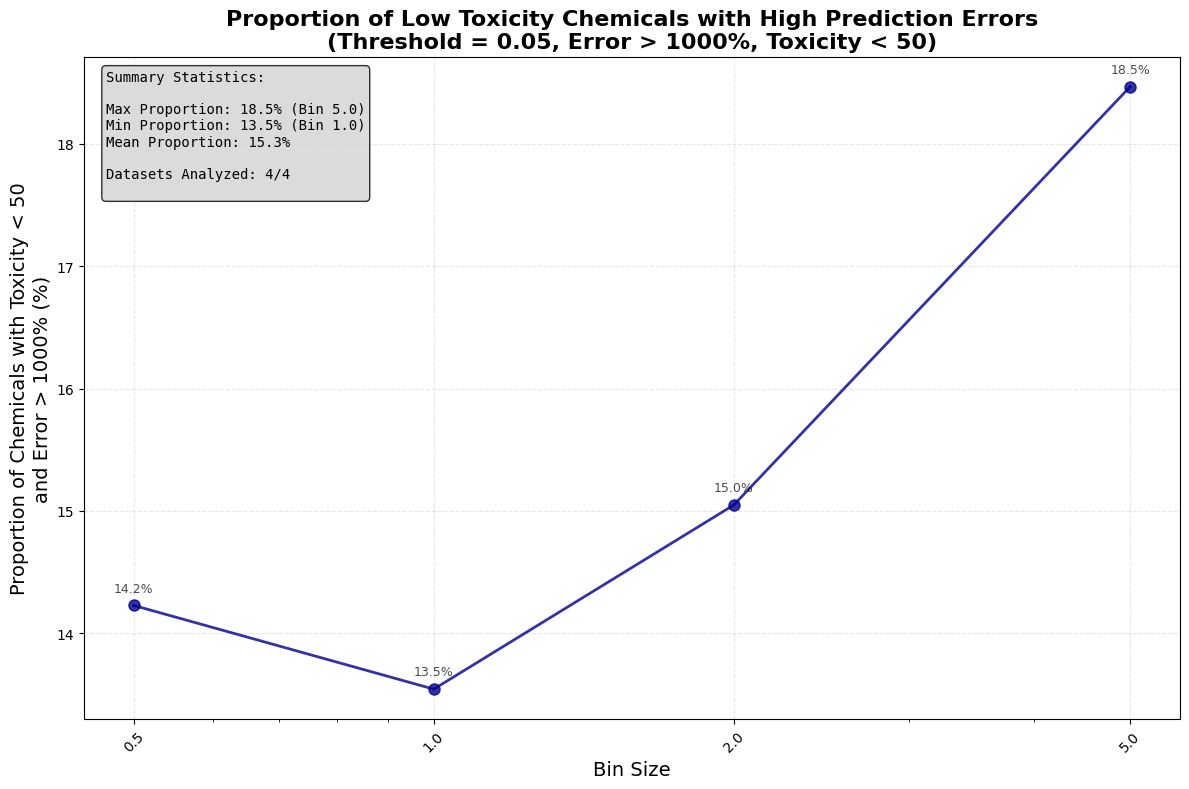


DETAILED RESULTS TABLE
Bin Size   Proportion   Low Tox Count   High Error Count   Total Samples  
--------------------------------------------------------------------------------
0.5        0.142        731.0           104.0              14697.0        
1.0        0.135        731.0           99.0               14697.0        
2.0        0.150        731.0           110.0              14697.0        
5.0        0.185        731.0           135.0              14697.0        

MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE
Bin Size   Mean Error %    Median Error % 
------------------------------------------------------------
0.5        662.0           8.2            
1.0        201.2           5.5            
2.0        229.0           8.0            
5.0        158.0           10.2           


In [26]:
# PROPORTIONS WITH FILTERED MF AND WEIGHTING


def plot_proportion_by_bin_size(threshold=1, error_threshold=1000, toxicity_benchmark=50, 
                               data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/temp_test_filt_weight",
                               figsize=(12, 8)):
    """
    Create a line plot showing the proportion of low toxicity chemicals with high errors across bin sizes.
    
    Parameters:
    -----------
    threshold : float
        The threshold value to use for all datasets (default: 1)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
    figsize : tuple
        Figure size for the plot (default: (12, 8))
    """
    
    # Define bin sizes to analyze
    bin_sizes =  [0.5, 1, 2, 5] #[0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
    # bin_sizes =  [0.5, 1, 10, 25, 100, 200, 1000]
    # Storage for results
    results = []
    
    print(f"Analyzing proportion for threshold={threshold}, error_threshold={error_threshold}%, toxicity_benchmark={toxicity_benchmark}")
    print("Processing bin sizes...")
    
    for bin_size in bin_sizes:
        # Convert bin_size and threshold to string format used in filenames
        if bin_size < 1:
            bin_str = f"bin{str(bin_size).replace('.', '_')}"
        else:
            bin_str = f"bin{int(bin_size)}"
        
        if threshold == 0:
            thresh_str = "thresh_zero"
        elif threshold < 1:
            thresh_str = f"thresh{str(threshold).replace('.', '_')}"
        else:
            thresh_str = f"thresh{int(threshold)}"
        
        # Construct filename
        dataset_name = f"cond_enc_{bin_str}_{thresh_str}_df_spectra"
        filename = f"{dataset_name}.parquet"
        file_path = os.path.join(data_folder, filename)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"  Bin {bin_size}: File not found")
            continue
        
        try:
            # Load the data
            df = pd.read_parquet(file_path)
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']
            y_true_response = df['Response']
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)

            # # Convert from reciprocal back to log scale, then to original scale
            # y_pred_log_actual = 1.0 / y_pred_log
            # y_pred_response = np.exp(y_pred_log_actual)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:
                print(f"  Bin {bin_size}: Too few samples ({len(y_pred_response_clean)})")
                continue
            
            # Calculate absolute percent error
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate proportion
            low_toxicity_mask = y_true_response_clean < toxicity_benchmark
            high_error_mask = individual_errors > error_threshold
            low_tox_high_error_mask = low_toxicity_mask & high_error_mask
            
            low_toxicity_count = low_toxicity_mask.sum()
            low_tox_high_error_count = low_tox_high_error_mask.sum()
            
            if low_toxicity_count > 0:
                proportion = low_tox_high_error_count / low_toxicity_count
            else:
                proportion = 0
            
            results.append({
                'bin_size': bin_size,
                'proportion': proportion,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'total_samples': len(y_pred_response_clean),
                'mean_error': individual_errors.mean(),
                'median_error': individual_errors.median()
            })
            
            print(f"  Bin {bin_size}: {proportion:.3f} ({proportion*100:.1f}%) - {low_tox_high_error_count}/{low_toxicity_count} low tox with high error")
            
        except Exception as e:
            print(f"  Bin {bin_size}: Error - {str(e)}")
            continue
    
    if not results:
        print("No valid data found for any bin size!")
        return None
    
    # Convert to DataFrame for easier plotting
    df_results = pd.DataFrame(results)
    
    # Create the line plot
    plt.figure(figsize=figsize)
    
    # Main line plot
    plt.plot(df_results['bin_size'], df_results['proportion'] * 100, 
             marker='o', linewidth=2, markersize=8, color='darkblue', alpha=0.8)
    
    # Add data points with values
    for _, row in df_results.iterrows():
        plt.annotate(f'{row["proportion"]*100:.1f}%', 
                    (row['bin_size'], row['proportion']*100),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, alpha=0.7)
    
    # Formatting
    plt.xlabel('Bin Size', fontsize=14)
    plt.ylabel(f'Proportion of Chemicals with Toxicity < {toxicity_benchmark}\nand Error > {error_threshold}% (%)', fontsize=14)
    plt.title(f'Proportion of Low Toxicity Chemicals with High Prediction Errors\n(Threshold = {threshold}, Error > {error_threshold}%, Toxicity < {toxicity_benchmark})', 
              fontsize=16, fontweight='bold')
    
    # Set x-axis to log scale for better visibility
    plt.xscale('log')
    plt.xticks(df_results['bin_size'], [str(x) for x in df_results['bin_size']], rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add summary statistics as text box
    max_prop = df_results['proportion'].max()
    min_prop = df_results['proportion'].min()
    max_bin = df_results.loc[df_results['proportion'].idxmax(), 'bin_size']
    min_bin = df_results.loc[df_results['proportion'].idxmin(), 'bin_size']
    
    stats_text = f"""Summary Statistics:
    
Max Proportion: {max_prop*100:.1f}% (Bin {max_bin})
Min Proportion: {min_prop*100:.1f}% (Bin {min_bin})
Mean Proportion: {df_results['proportion'].mean()*100:.1f}%

Datasets Analyzed: {len(df_results)}/{len(bin_sizes)}
    """
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS TABLE")
    print(f"{'='*80}")
    print(f"{'Bin Size':<10} {'Proportion':<12} {'Low Tox Count':<15} {'High Error Count':<18} {'Total Samples':<15}")
    print(f"{'-'*80}")
    
    for _, row in df_results.iterrows():
        print(f"{row['bin_size']:<10} {row['proportion']:<12.3f} {row['low_toxicity_count']:<15} {row['low_tox_high_error_count']:<18} {row['total_samples']:<15}")
    
    return df_results

# Usage examples with easily changeable parameters:

# Default parameters
results = plot_proportion_by_bin_size(
    threshold=0.05,              
    error_threshold=1000,       
    toxicity_benchmark=50     
)

# Print mean and median percent error table
if results is not None:
    print(f"\n{'='*60}")
    print(f"MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE")
    print(f"{'='*60}")
    print(f"{'Bin Size':<10} {'Mean Error %':<15} {'Median Error %':<15}")
    print(f"{'-'*60}")
    
    for _, row in results.iterrows():
        print(f"{row['bin_size']:<10} {row['mean_error']:<15.1f} {row['median_error']:<15.1f}")

Analyzing proportion for threshold=0.05, error_threshold=1000%, toxicity_benchmark=50
Processing bin sizes...
  Bin 0.5: 0.129 (12.9%) - 94/731 low tox with high error
  Bin 1: 0.129 (12.9%) - 94/731 low tox with high error
  Bin 2: 0.146 (14.6%) - 107/731 low tox with high error
  Bin 5: 0.192 (19.2%) - 140/731 low tox with high error


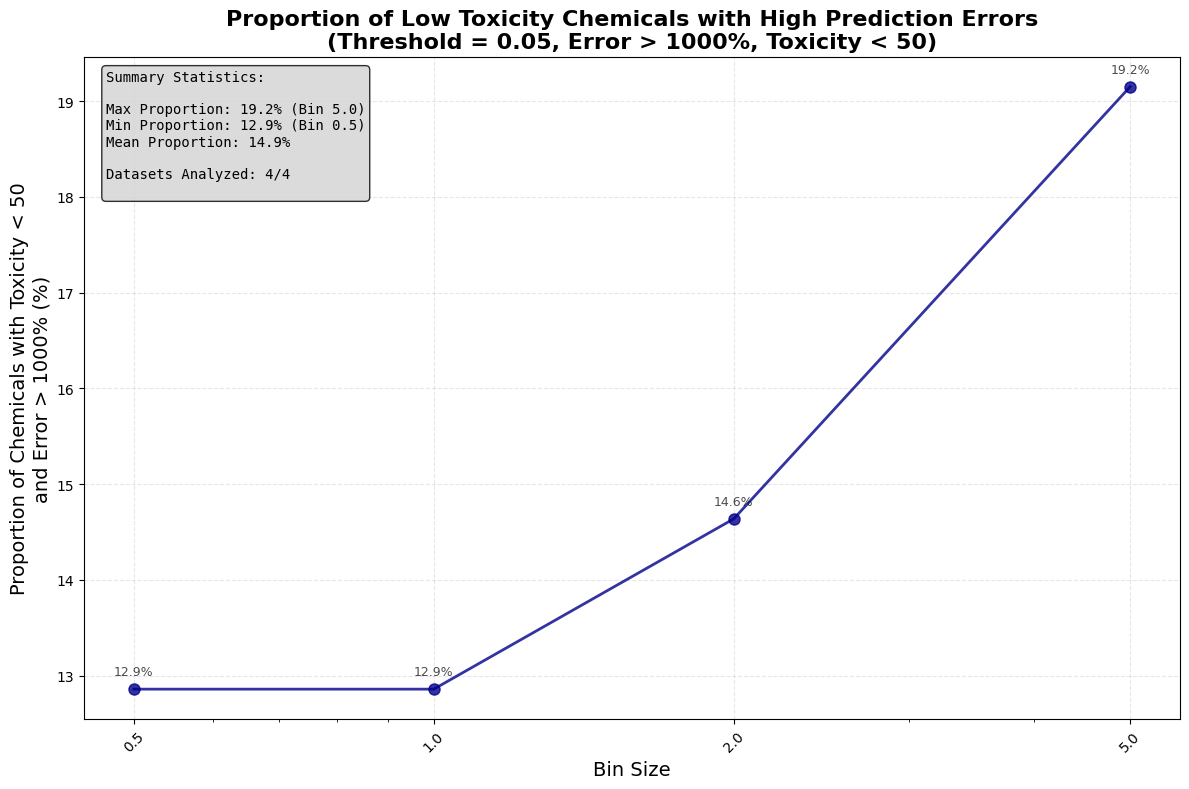


DETAILED RESULTS TABLE
Bin Size   Proportion   Low Tox Count   High Error Count   Total Samples  
--------------------------------------------------------------------------------
0.5        0.129        731.0           94.0               14697.0        
1.0        0.129        731.0           94.0               14697.0        
2.0        0.146        731.0           107.0              14697.0        
5.0        0.192        731.0           140.0              14697.0        

MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE
Bin Size   Mean Error %    Median Error % 
------------------------------------------------------------
0.5        754.4           4.0            
1.0        183.9           4.8            
2.0        209.9           8.4            
5.0        211.9           13.7           


In [32]:
# NO FILETERTING MF AND YES WEIGHTING

def plot_proportion_by_bin_size(threshold=1, error_threshold=1000, toxicity_benchmark=50, 
                               data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/temp_test_nofilt_weight",
                               figsize=(12, 8)):
    """
    Create a line plot showing the proportion of low toxicity chemicals with high errors across bin sizes.
    
    Parameters:
    -----------
    threshold : float
        The threshold value to use for all datasets (default: 1)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
    figsize : tuple
        Figure size for the plot (default: (12, 8))
    """
    
    # Define bin sizes to analyze
    bin_sizes =  [0.5, 1, 2, 5] #[0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
    # bin_sizes =  [0.5, 1, 10, 25, 100, 200, 1000]
    # Storage for results
    results = []
    
    print(f"Analyzing proportion for threshold={threshold}, error_threshold={error_threshold}%, toxicity_benchmark={toxicity_benchmark}")
    print("Processing bin sizes...")
    
    for bin_size in bin_sizes:
        # Convert bin_size and threshold to string format used in filenames
        if bin_size < 1:
            bin_str = f"bin{str(bin_size).replace('.', '_')}"
        else:
            bin_str = f"bin{int(bin_size)}"
        
        if threshold == 0:
            thresh_str = "thresh_zero"
        elif threshold < 1:
            thresh_str = f"thresh{str(threshold).replace('.', '_')}"
        else:
            thresh_str = f"thresh{int(threshold)}"
        
        # Construct filename
        dataset_name = f"cond_enc_{bin_str}_{thresh_str}_df_spectra"
        filename = f"{dataset_name}.parquet"
        file_path = os.path.join(data_folder, filename)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"  Bin {bin_size}: File not found")
            continue
        
        try:
            # Load the data
            df = pd.read_parquet(file_path)
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']
            y_true_response = df['Response']
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)

            # # Convert from reciprocal back to log scale, then to original scale
            # y_pred_log_actual = 1.0 / y_pred_log
            # y_pred_response = np.exp(y_pred_log_actual)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:
                print(f"  Bin {bin_size}: Too few samples ({len(y_pred_response_clean)})")
                continue
            
            # Calculate absolute percent error
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate proportion
            low_toxicity_mask = y_true_response_clean < toxicity_benchmark
            high_error_mask = individual_errors > error_threshold
            low_tox_high_error_mask = low_toxicity_mask & high_error_mask
            
            low_toxicity_count = low_toxicity_mask.sum()
            low_tox_high_error_count = low_tox_high_error_mask.sum()
            
            if low_toxicity_count > 0:
                proportion = low_tox_high_error_count / low_toxicity_count
            else:
                proportion = 0
            
            results.append({
                'bin_size': bin_size,
                'proportion': proportion,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'total_samples': len(y_pred_response_clean),
                'mean_error': individual_errors.mean(),
                'median_error': individual_errors.median()
            })
            
            print(f"  Bin {bin_size}: {proportion:.3f} ({proportion*100:.1f}%) - {low_tox_high_error_count}/{low_toxicity_count} low tox with high error")
            
        except Exception as e:
            print(f"  Bin {bin_size}: Error - {str(e)}")
            continue
    
    if not results:
        print("No valid data found for any bin size!")
        return None
    
    # Convert to DataFrame for easier plotting
    df_results = pd.DataFrame(results)
    
    # Create the line plot
    plt.figure(figsize=figsize)
    
    # Main line plot
    plt.plot(df_results['bin_size'], df_results['proportion'] * 100, 
             marker='o', linewidth=2, markersize=8, color='darkblue', alpha=0.8)
    
    # Add data points with values
    for _, row in df_results.iterrows():
        plt.annotate(f'{row["proportion"]*100:.1f}%', 
                    (row['bin_size'], row['proportion']*100),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, alpha=0.7)
    
    # Formatting
    plt.xlabel('Bin Size', fontsize=14)
    plt.ylabel(f'Proportion of Chemicals with Toxicity < {toxicity_benchmark}\nand Error > {error_threshold}% (%)', fontsize=14)
    plt.title(f'Proportion of Low Toxicity Chemicals with High Prediction Errors\n(Threshold = {threshold}, Error > {error_threshold}%, Toxicity < {toxicity_benchmark})', 
              fontsize=16, fontweight='bold')
    
    # Set x-axis to log scale for better visibility
    plt.xscale('log')
    plt.xticks(df_results['bin_size'], [str(x) for x in df_results['bin_size']], rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add summary statistics as text box
    max_prop = df_results['proportion'].max()
    min_prop = df_results['proportion'].min()
    max_bin = df_results.loc[df_results['proportion'].idxmax(), 'bin_size']
    min_bin = df_results.loc[df_results['proportion'].idxmin(), 'bin_size']
    
    stats_text = f"""Summary Statistics:
    
Max Proportion: {max_prop*100:.1f}% (Bin {max_bin})
Min Proportion: {min_prop*100:.1f}% (Bin {min_bin})
Mean Proportion: {df_results['proportion'].mean()*100:.1f}%

Datasets Analyzed: {len(df_results)}/{len(bin_sizes)}
    """
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS TABLE")
    print(f"{'='*80}")
    print(f"{'Bin Size':<10} {'Proportion':<12} {'Low Tox Count':<15} {'High Error Count':<18} {'Total Samples':<15}")
    print(f"{'-'*80}")
    
    for _, row in df_results.iterrows():
        print(f"{row['bin_size']:<10} {row['proportion']:<12.3f} {row['low_toxicity_count']:<15} {row['low_tox_high_error_count']:<18} {row['total_samples']:<15}")
    
    return df_results

# Usage examples with easily changeable parameters:

# Default parameters
results = plot_proportion_by_bin_size(
    threshold=0.05,              
    error_threshold=1000,       
    toxicity_benchmark=50     
)

# Print mean and median percent error table
if results is not None:
    print(f"\n{'='*60}")
    print(f"MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE")
    print(f"{'='*60}")
    print(f"{'Bin Size':<10} {'Mean Error %':<15} {'Median Error %':<15}")
    print(f"{'-'*60}")
    
    for _, row in results.iterrows():
        print(f"{row['bin_size']:<10} {row['mean_error']:<15.1f} {row['median_error']:<15.1f}")

# Proportion Comparisons Super Test Set

Analyzing proportion for threshold=0.05, error_threshold=1000%, toxicity_benchmark=50
Processing bin sizes...
  Bin 0.5: 0.584 (58.4%) - 45/77 low tox with high error
  Bin 1: 0.558 (55.8%) - 43/77 low tox with high error
  Bin 2: 0.662 (66.2%) - 51/77 low tox with high error
  Bin 5: 0.636 (63.6%) - 49/77 low tox with high error


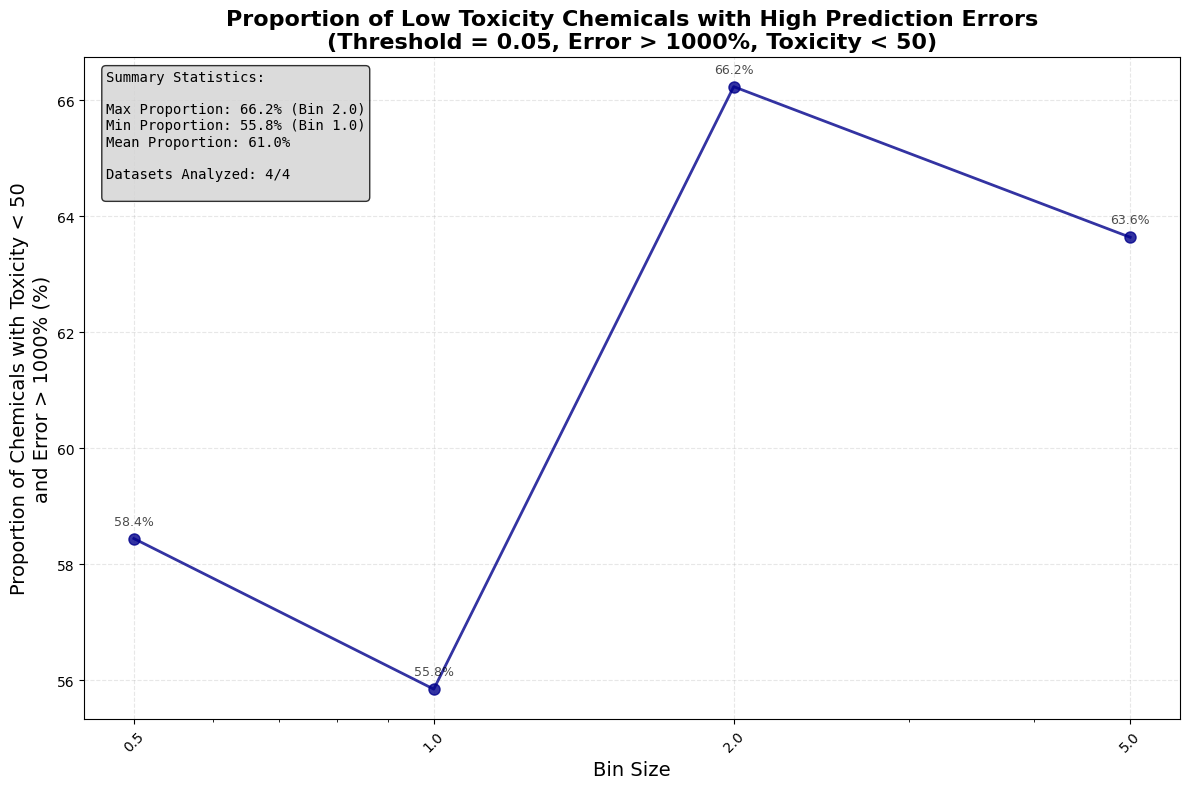


DETAILED RESULTS TABLE
Bin Size   Proportion   Low Tox Count   High Error Count   Total Samples  
--------------------------------------------------------------------------------
0.5        0.584        77.0            45.0               407.0          
1.0        0.558        77.0            43.0               407.0          
2.0        0.662        77.0            51.0               407.0          
5.0        0.636        77.0            49.0               407.0          

MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE
Bin Size   Mean Error %    Median Error % 
------------------------------------------------------------
0.5        5292.4          110.1          
1.0        10166.3         99.3           
2.0        3651.9          134.0          
5.0        9533.3          151.0          


In [28]:
def plot_proportion_by_bin_size(threshold=1, error_threshold=1000, toxicity_benchmark=50, 
                               data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_supertest_outputs",
                               figsize=(12, 8)):
    """
    Create a line plot showing the proportion of low toxicity chemicals with high errors across bin sizes.
    
    Parameters:
    -----------
    threshold : float
        The threshold value to use for all datasets (default: 1)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
    figsize : tuple
        Figure size for the plot (default: (12, 8))
    """
    
    # Define bin sizes to analyze
    bin_sizes =  [0.5, 1, 2, 5] #[0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
    # bin_sizes =  [0.5, 1, 10, 25, 100, 200, 1000]
    # Storage for results
    results = []
    
    print(f"Analyzing proportion for threshold={threshold}, error_threshold={error_threshold}%, toxicity_benchmark={toxicity_benchmark}")
    print("Processing bin sizes...")
    
    for bin_size in bin_sizes:
        # Convert bin_size and threshold to string format used in filenames
        if bin_size < 1:
            bin_str = f"bin{str(bin_size).replace('.', '_')}"
        else:
            bin_str = f"bin{int(bin_size)}"
        
        if threshold == 0:
            thresh_str = "thresh_zero"
        elif threshold < 1:
            thresh_str = f"thresh{str(threshold).replace('.', '_')}"
        else:
            thresh_str = f"thresh{int(threshold)}"
        
        # Construct filename
        dataset_name = f"super_test_cond_enc_{bin_str}_{thresh_str}_df_spectra"
        filename = f"{dataset_name}.parquet"
        file_path = os.path.join(data_folder, filename)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"  Bin {bin_size}: File not found")
            continue
        
        try:
            # Load the data
            df = pd.read_parquet(file_path)
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']
            y_true_response = df['Response']
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)

            # # Convert from reciprocal back to log scale, then to original scale
            # y_pred_log_actual = 1.0 / y_pred_log
            # y_pred_response = np.exp(y_pred_log_actual)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:
                print(f"  Bin {bin_size}: Too few samples ({len(y_pred_response_clean)})")
                continue
            
            # Calculate absolute percent error
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate proportion
            low_toxicity_mask = y_true_response_clean < toxicity_benchmark
            high_error_mask = individual_errors > error_threshold
            low_tox_high_error_mask = low_toxicity_mask & high_error_mask
            
            low_toxicity_count = low_toxicity_mask.sum()
            low_tox_high_error_count = low_tox_high_error_mask.sum()
            
            if low_toxicity_count > 0:
                proportion = low_tox_high_error_count / low_toxicity_count
            else:
                proportion = 0
            
            results.append({
                'bin_size': bin_size,
                'proportion': proportion,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'total_samples': len(y_pred_response_clean),
                'mean_error': individual_errors.mean(),
                'median_error': individual_errors.median()
            })
            
            print(f"  Bin {bin_size}: {proportion:.3f} ({proportion*100:.1f}%) - {low_tox_high_error_count}/{low_toxicity_count} low tox with high error")
            
        except Exception as e:
            print(f"  Bin {bin_size}: Error - {str(e)}")
            continue
    
    if not results:
        print("No valid data found for any bin size!")
        return None
    
    # Convert to DataFrame for easier plotting
    df_results = pd.DataFrame(results)
    
    # Create the line plot
    plt.figure(figsize=figsize)
    
    # Main line plot
    plt.plot(df_results['bin_size'], df_results['proportion'] * 100, 
             marker='o', linewidth=2, markersize=8, color='darkblue', alpha=0.8)
    
    # Add data points with values
    for _, row in df_results.iterrows():
        plt.annotate(f'{row["proportion"]*100:.1f}%', 
                    (row['bin_size'], row['proportion']*100),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, alpha=0.7)
    
    # Formatting
    plt.xlabel('Bin Size', fontsize=14)
    plt.ylabel(f'Proportion of Chemicals with Toxicity < {toxicity_benchmark}\nand Error > {error_threshold}% (%)', fontsize=14)
    plt.title(f'Proportion of Low Toxicity Chemicals with High Prediction Errors\n(Threshold = {threshold}, Error > {error_threshold}%, Toxicity < {toxicity_benchmark})', 
              fontsize=16, fontweight='bold')
    
    # Set x-axis to log scale for better visibility
    plt.xscale('log')
    plt.xticks(df_results['bin_size'], [str(x) for x in df_results['bin_size']], rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add summary statistics as text box
    max_prop = df_results['proportion'].max()
    min_prop = df_results['proportion'].min()
    max_bin = df_results.loc[df_results['proportion'].idxmax(), 'bin_size']
    min_bin = df_results.loc[df_results['proportion'].idxmin(), 'bin_size']
    
    stats_text = f"""Summary Statistics:
    
Max Proportion: {max_prop*100:.1f}% (Bin {max_bin})
Min Proportion: {min_prop*100:.1f}% (Bin {min_bin})
Mean Proportion: {df_results['proportion'].mean()*100:.1f}%

Datasets Analyzed: {len(df_results)}/{len(bin_sizes)}
    """
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS TABLE")
    print(f"{'='*80}")
    print(f"{'Bin Size':<10} {'Proportion':<12} {'Low Tox Count':<15} {'High Error Count':<18} {'Total Samples':<15}")
    print(f"{'-'*80}")
    
    for _, row in df_results.iterrows():
        print(f"{row['bin_size']:<10} {row['proportion']:<12.3f} {row['low_toxicity_count']:<15} {row['low_tox_high_error_count']:<18} {row['total_samples']:<15}")
    
    return df_results

# Usage examples with easily changeable parameters:

# Default parameters
results = plot_proportion_by_bin_size(
    threshold=0.05,              
    error_threshold=1000,       
    toxicity_benchmark=50     
)

# Print mean and median percent error table
if results is not None:
    print(f"\n{'='*60}")
    print(f"MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE")
    print(f"{'='*60}")
    print(f"{'Bin Size':<10} {'Mean Error %':<15} {'Median Error %':<15}")
    print(f"{'-'*60}")
    
    for _, row in results.iterrows():
        print(f"{row['bin_size']:<10} {row['mean_error']:<15.1f} {row['median_error']:<15.1f}")

Analyzing proportion for threshold=0.05, error_threshold=1000%, toxicity_benchmark=50
Processing bin sizes...
  Bin 0.5: 0.519 (51.9%) - 40/77 low tox with high error
  Bin 1: 0.481 (48.1%) - 37/77 low tox with high error
  Bin 2: 0.558 (55.8%) - 43/77 low tox with high error
  Bin 5: 0.649 (64.9%) - 50/77 low tox with high error


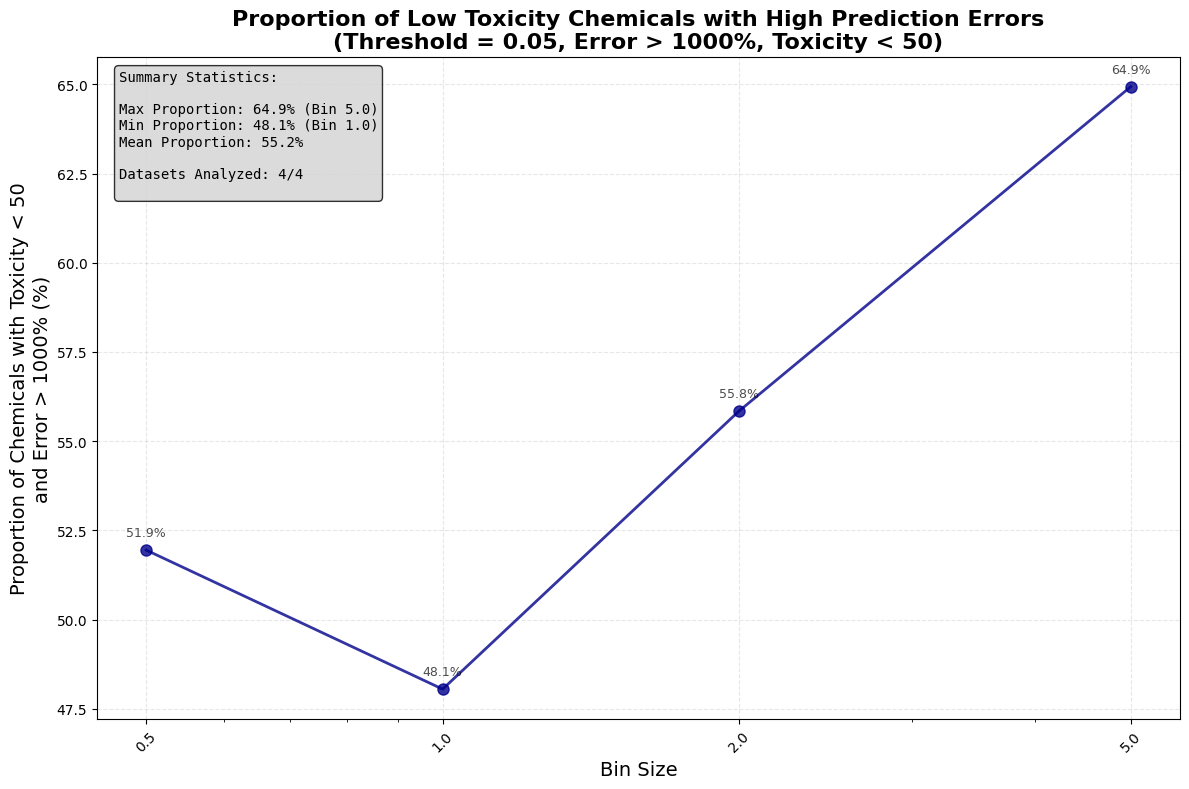


DETAILED RESULTS TABLE
Bin Size   Proportion   Low Tox Count   High Error Count   Total Samples  
--------------------------------------------------------------------------------
0.5        0.519        77.0            40.0               407.0          
1.0        0.481        77.0            37.0               407.0          
2.0        0.558        77.0            43.0               407.0          
5.0        0.649        77.0            50.0               407.0          

MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE
Bin Size   Mean Error %    Median Error % 
------------------------------------------------------------
0.5        9963.5          113.7          
1.0        14412.3         96.0           
2.0        2966.3          141.3          
5.0        8485.9          98.0           


In [29]:
def plot_proportion_by_bin_size(threshold=1, error_threshold=1000, toxicity_benchmark=50, 
                               data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/temp_test_nofilt_super_test",
                               figsize=(12, 8)):
    """
    Create a line plot showing the proportion of low toxicity chemicals with high errors across bin sizes.
    
    Parameters:
    -----------
    threshold : float
        The threshold value to use for all datasets (default: 1)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
    figsize : tuple
        Figure size for the plot (default: (12, 8))
    """
    
    # Define bin sizes to analyze
    bin_sizes =  [0.5, 1, 2, 5] #[0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
    # bin_sizes =  [0.5, 1, 10, 25, 100, 200, 1000]
    # Storage for results
    results = []
    
    print(f"Analyzing proportion for threshold={threshold}, error_threshold={error_threshold}%, toxicity_benchmark={toxicity_benchmark}")
    print("Processing bin sizes...")
    
    for bin_size in bin_sizes:
        # Convert bin_size and threshold to string format used in filenames
        if bin_size < 1:
            bin_str = f"bin{str(bin_size).replace('.', '_')}"
        else:
            bin_str = f"bin{int(bin_size)}"
        
        if threshold == 0:
            thresh_str = "thresh_zero"
        elif threshold < 1:
            thresh_str = f"thresh{str(threshold).replace('.', '_')}"
        else:
            thresh_str = f"thresh{int(threshold)}"
        
        # Construct filename
        dataset_name = f"super_test_cond_enc_{bin_str}_{thresh_str}_df_spectra"
        filename = f"{dataset_name}.parquet"
        file_path = os.path.join(data_folder, filename)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"  Bin {bin_size}: File not found")
            continue
        
        try:
            # Load the data
            df = pd.read_parquet(file_path)
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']
            y_true_response = df['Response']
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)

            # # Convert from reciprocal back to log scale, then to original scale
            # y_pred_log_actual = 1.0 / y_pred_log
            # y_pred_response = np.exp(y_pred_log_actual)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:
                print(f"  Bin {bin_size}: Too few samples ({len(y_pred_response_clean)})")
                continue
            
            # Calculate absolute percent error
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate proportion
            low_toxicity_mask = y_true_response_clean < toxicity_benchmark
            high_error_mask = individual_errors > error_threshold
            low_tox_high_error_mask = low_toxicity_mask & high_error_mask
            
            low_toxicity_count = low_toxicity_mask.sum()
            low_tox_high_error_count = low_tox_high_error_mask.sum()
            
            if low_toxicity_count > 0:
                proportion = low_tox_high_error_count / low_toxicity_count
            else:
                proportion = 0
            
            results.append({
                'bin_size': bin_size,
                'proportion': proportion,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'total_samples': len(y_pred_response_clean),
                'mean_error': individual_errors.mean(),
                'median_error': individual_errors.median()
            })
            
            print(f"  Bin {bin_size}: {proportion:.3f} ({proportion*100:.1f}%) - {low_tox_high_error_count}/{low_toxicity_count} low tox with high error")
            
        except Exception as e:
            print(f"  Bin {bin_size}: Error - {str(e)}")
            continue
    
    if not results:
        print("No valid data found for any bin size!")
        return None
    
    # Convert to DataFrame for easier plotting
    df_results = pd.DataFrame(results)
    
    # Create the line plot
    plt.figure(figsize=figsize)
    
    # Main line plot
    plt.plot(df_results['bin_size'], df_results['proportion'] * 100, 
             marker='o', linewidth=2, markersize=8, color='darkblue', alpha=0.8)
    
    # Add data points with values
    for _, row in df_results.iterrows():
        plt.annotate(f'{row["proportion"]*100:.1f}%', 
                    (row['bin_size'], row['proportion']*100),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, alpha=0.7)
    
    # Formatting
    plt.xlabel('Bin Size', fontsize=14)
    plt.ylabel(f'Proportion of Chemicals with Toxicity < {toxicity_benchmark}\nand Error > {error_threshold}% (%)', fontsize=14)
    plt.title(f'Proportion of Low Toxicity Chemicals with High Prediction Errors\n(Threshold = {threshold}, Error > {error_threshold}%, Toxicity < {toxicity_benchmark})', 
              fontsize=16, fontweight='bold')
    
    # Set x-axis to log scale for better visibility
    plt.xscale('log')
    plt.xticks(df_results['bin_size'], [str(x) for x in df_results['bin_size']], rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add summary statistics as text box
    max_prop = df_results['proportion'].max()
    min_prop = df_results['proportion'].min()
    max_bin = df_results.loc[df_results['proportion'].idxmax(), 'bin_size']
    min_bin = df_results.loc[df_results['proportion'].idxmin(), 'bin_size']
    
    stats_text = f"""Summary Statistics:
    
Max Proportion: {max_prop*100:.1f}% (Bin {max_bin})
Min Proportion: {min_prop*100:.1f}% (Bin {min_bin})
Mean Proportion: {df_results['proportion'].mean()*100:.1f}%

Datasets Analyzed: {len(df_results)}/{len(bin_sizes)}
    """
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS TABLE")
    print(f"{'='*80}")
    print(f"{'Bin Size':<10} {'Proportion':<12} {'Low Tox Count':<15} {'High Error Count':<18} {'Total Samples':<15}")
    print(f"{'-'*80}")
    
    for _, row in df_results.iterrows():
        print(f"{row['bin_size']:<10} {row['proportion']:<12.3f} {row['low_toxicity_count']:<15} {row['low_tox_high_error_count']:<18} {row['total_samples']:<15}")
    
    return df_results

# Usage examples with easily changeable parameters:

# Default parameters
results = plot_proportion_by_bin_size(
    threshold=0.05,              
    error_threshold=1000,       
    toxicity_benchmark=50     
)

# Print mean and median percent error table
if results is not None:
    print(f"\n{'='*60}")
    print(f"MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE")
    print(f"{'='*60}")
    print(f"{'Bin Size':<10} {'Mean Error %':<15} {'Median Error %':<15}")
    print(f"{'-'*60}")
    
    for _, row in results.iterrows():
        print(f"{row['bin_size']:<10} {row['mean_error']:<15.1f} {row['median_error']:<15.1f}")

Analyzing proportion for threshold=0.05, error_threshold=1000%, toxicity_benchmark=50
Processing bin sizes...
  Bin 0.5: 0.506 (50.6%) - 39/77 low tox with high error


  Bin 1: 0.442 (44.2%) - 34/77 low tox with high error
  Bin 2: 0.571 (57.1%) - 44/77 low tox with high error
  Bin 5: 0.584 (58.4%) - 45/77 low tox with high error


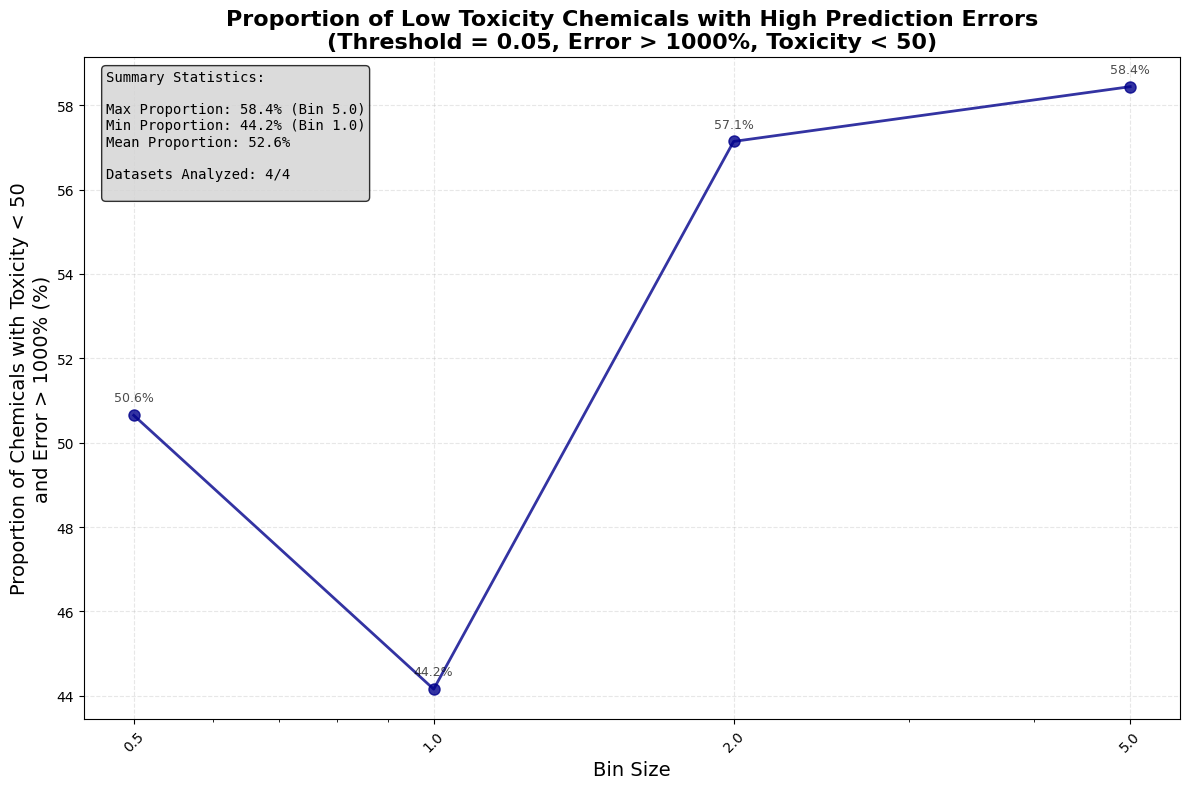


DETAILED RESULTS TABLE
Bin Size   Proportion   Low Tox Count   High Error Count   Total Samples  
--------------------------------------------------------------------------------
0.5        0.506        77.0            39.0               407.0          
1.0        0.442        77.0            34.0               407.0          
2.0        0.571        77.0            44.0               407.0          
5.0        0.584        77.0            45.0               407.0          

MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE
Bin Size   Mean Error %    Median Error % 
------------------------------------------------------------
0.5        5272.1          103.4          
1.0        5434.6          95.4           
2.0        2843.9          136.1          
5.0        5900.5          98.7           


In [30]:
def plot_proportion_by_bin_size(threshold=1, error_threshold=1000, toxicity_benchmark=50, 
                               data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/temp_test_filt_weight_super_test",
                               figsize=(12, 8)):
    """
    Create a line plot showing the proportion of low toxicity chemicals with high errors across bin sizes.
    
    Parameters:
    -----------
    threshold : float
        The threshold value to use for all datasets (default: 1)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
    figsize : tuple
        Figure size for the plot (default: (12, 8))
    """
    
    # Define bin sizes to analyze
    bin_sizes =  [0.5, 1, 2, 5] #[0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
    # bin_sizes =  [0.5, 1, 10, 25, 100, 200, 1000]
    # Storage for results
    results = []
    
    print(f"Analyzing proportion for threshold={threshold}, error_threshold={error_threshold}%, toxicity_benchmark={toxicity_benchmark}")
    print("Processing bin sizes...")
    
    for bin_size in bin_sizes:
        # Convert bin_size and threshold to string format used in filenames
        if bin_size < 1:
            bin_str = f"bin{str(bin_size).replace('.', '_')}"
        else:
            bin_str = f"bin{int(bin_size)}"
        
        if threshold == 0:
            thresh_str = "thresh_zero"
        elif threshold < 1:
            thresh_str = f"thresh{str(threshold).replace('.', '_')}"
        else:
            thresh_str = f"thresh{int(threshold)}"
        
        # Construct filename
        dataset_name = f"super_test_cond_enc_{bin_str}_{thresh_str}_df_spectra"
        filename = f"{dataset_name}.parquet"
        file_path = os.path.join(data_folder, filename)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"  Bin {bin_size}: File not found")
            continue
        
        try:
            # Load the data
            df = pd.read_parquet(file_path)
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']
            y_true_response = df['Response']
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)

            # # Convert from reciprocal back to log scale, then to original scale
            # y_pred_log_actual = 1.0 / y_pred_log
            # y_pred_response = np.exp(y_pred_log_actual)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:
                print(f"  Bin {bin_size}: Too few samples ({len(y_pred_response_clean)})")
                continue
            
            # Calculate absolute percent error
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate proportion
            low_toxicity_mask = y_true_response_clean < toxicity_benchmark
            high_error_mask = individual_errors > error_threshold
            low_tox_high_error_mask = low_toxicity_mask & high_error_mask
            
            low_toxicity_count = low_toxicity_mask.sum()
            low_tox_high_error_count = low_tox_high_error_mask.sum()
            
            if low_toxicity_count > 0:
                proportion = low_tox_high_error_count / low_toxicity_count
            else:
                proportion = 0
            
            results.append({
                'bin_size': bin_size,
                'proportion': proportion,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'total_samples': len(y_pred_response_clean),
                'mean_error': individual_errors.mean(),
                'median_error': individual_errors.median()
            })
            
            print(f"  Bin {bin_size}: {proportion:.3f} ({proportion*100:.1f}%) - {low_tox_high_error_count}/{low_toxicity_count} low tox with high error")
            
        except Exception as e:
            print(f"  Bin {bin_size}: Error - {str(e)}")
            continue
    
    if not results:
        print("No valid data found for any bin size!")
        return None
    
    # Convert to DataFrame for easier plotting
    df_results = pd.DataFrame(results)
    
    # Create the line plot
    plt.figure(figsize=figsize)
    
    # Main line plot
    plt.plot(df_results['bin_size'], df_results['proportion'] * 100, 
             marker='o', linewidth=2, markersize=8, color='darkblue', alpha=0.8)
    
    # Add data points with values
    for _, row in df_results.iterrows():
        plt.annotate(f'{row["proportion"]*100:.1f}%', 
                    (row['bin_size'], row['proportion']*100),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, alpha=0.7)
    
    # Formatting
    plt.xlabel('Bin Size', fontsize=14)
    plt.ylabel(f'Proportion of Chemicals with Toxicity < {toxicity_benchmark}\nand Error > {error_threshold}% (%)', fontsize=14)
    plt.title(f'Proportion of Low Toxicity Chemicals with High Prediction Errors\n(Threshold = {threshold}, Error > {error_threshold}%, Toxicity < {toxicity_benchmark})', 
              fontsize=16, fontweight='bold')
    
    # Set x-axis to log scale for better visibility
    plt.xscale('log')
    plt.xticks(df_results['bin_size'], [str(x) for x in df_results['bin_size']], rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add summary statistics as text box
    max_prop = df_results['proportion'].max()
    min_prop = df_results['proportion'].min()
    max_bin = df_results.loc[df_results['proportion'].idxmax(), 'bin_size']
    min_bin = df_results.loc[df_results['proportion'].idxmin(), 'bin_size']
    
    stats_text = f"""Summary Statistics:
    
Max Proportion: {max_prop*100:.1f}% (Bin {max_bin})
Min Proportion: {min_prop*100:.1f}% (Bin {min_bin})
Mean Proportion: {df_results['proportion'].mean()*100:.1f}%

Datasets Analyzed: {len(df_results)}/{len(bin_sizes)}
    """
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS TABLE")
    print(f"{'='*80}")
    print(f"{'Bin Size':<10} {'Proportion':<12} {'Low Tox Count':<15} {'High Error Count':<18} {'Total Samples':<15}")
    print(f"{'-'*80}")
    
    for _, row in df_results.iterrows():
        print(f"{row['bin_size']:<10} {row['proportion']:<12.3f} {row['low_toxicity_count']:<15} {row['low_tox_high_error_count']:<18} {row['total_samples']:<15}")
    
    return df_results

# Usage examples with easily changeable parameters:

# Default parameters
results = plot_proportion_by_bin_size(
    threshold=0.05,              
    error_threshold=1000,       
    toxicity_benchmark=50     
)

# Print mean and median percent error table
if results is not None:
    print(f"\n{'='*60}")
    print(f"MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE")
    print(f"{'='*60}")
    print(f"{'Bin Size':<10} {'Mean Error %':<15} {'Median Error %':<15}")
    print(f"{'-'*60}")
    
    for _, row in results.iterrows():
        print(f"{row['bin_size']:<10} {row['mean_error']:<15.1f} {row['median_error']:<15.1f}")

Analyzing proportion for threshold=0.05, error_threshold=1000%, toxicity_benchmark=50
Processing bin sizes...
  Bin 0.5: 0.481 (48.1%) - 37/77 low tox with high error
  Bin 1: 0.442 (44.2%) - 34/77 low tox with high error
  Bin 2: 0.571 (57.1%) - 44/77 low tox with high error
  Bin 5: 0.636 (63.6%) - 49/77 low tox with high error


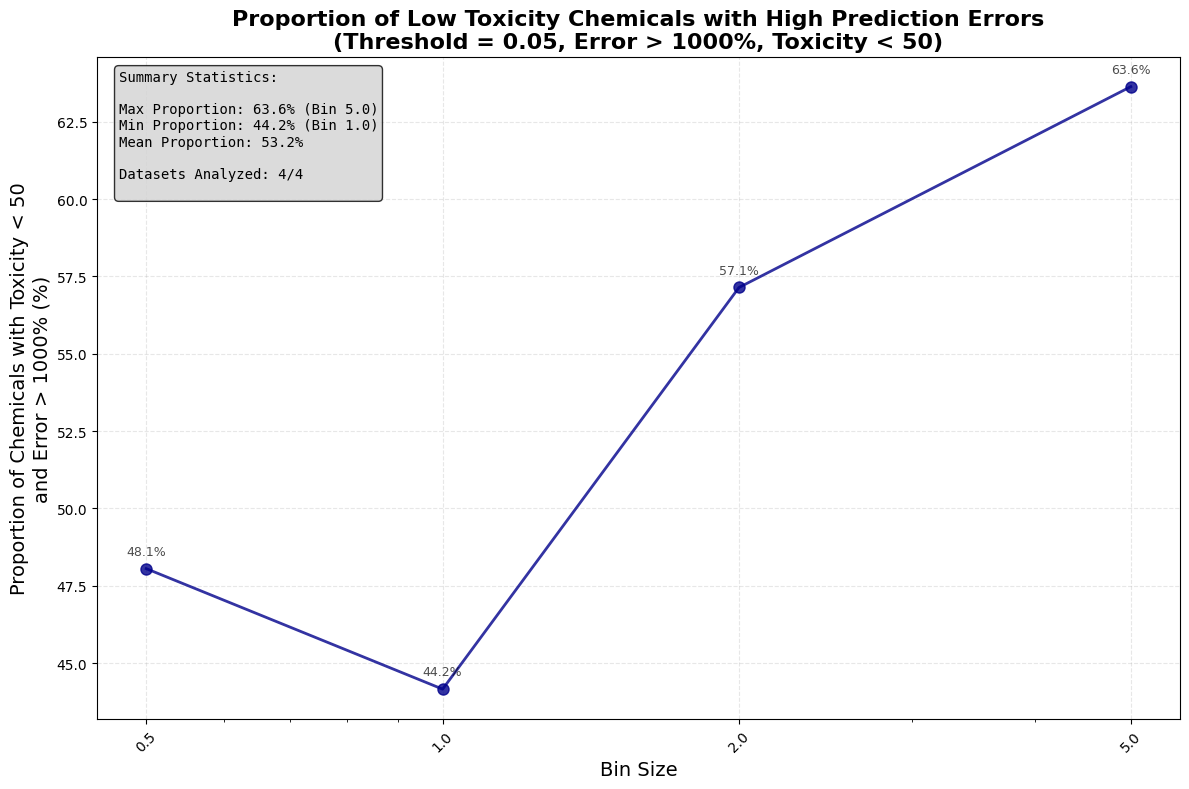


DETAILED RESULTS TABLE
Bin Size   Proportion   Low Tox Count   High Error Count   Total Samples  
--------------------------------------------------------------------------------
0.5        0.481        77.0            37.0               407.0          
1.0        0.442        77.0            34.0               407.0          
2.0        0.571        77.0            44.0               407.0          
5.0        0.636        77.0            49.0               407.0          

MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE
Bin Size   Mean Error %    Median Error % 
------------------------------------------------------------
0.5        8650.5          98.1           
1.0        8488.2          89.7           
2.0        2640.1          143.2          
5.0        4622.4          114.0          


In [31]:
def plot_proportion_by_bin_size(threshold=1, error_threshold=1000, toxicity_benchmark=50, 
                               data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/temp_test_nofilt_weight_super_test",
                               figsize=(12, 8)):
    """
    Create a line plot showing the proportion of low toxicity chemicals with high errors across bin sizes.
    
    Parameters:
    -----------
    threshold : float
        The threshold value to use for all datasets (default: 1)
    error_threshold : float
        Error threshold for analysis (default: 1000%)
    toxicity_benchmark : float
        Toxicity value benchmark for proportion analysis (default: 50)
    data_folder : str
        Path to the folder containing conditional encoder output files
    figsize : tuple
        Figure size for the plot (default: (12, 8))
    """
    
    # Define bin sizes to analyze
    bin_sizes =  [0.5, 1, 2, 5] #[0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
    # bin_sizes =  [0.5, 1, 10, 25, 100, 200, 1000]
    # Storage for results
    results = []
    
    print(f"Analyzing proportion for threshold={threshold}, error_threshold={error_threshold}%, toxicity_benchmark={toxicity_benchmark}")
    print("Processing bin sizes...")
    
    for bin_size in bin_sizes:
        # Convert bin_size and threshold to string format used in filenames
        if bin_size < 1:
            bin_str = f"bin{str(bin_size).replace('.', '_')}"
        else:
            bin_str = f"bin{int(bin_size)}"
        
        if threshold == 0:
            thresh_str = "thresh_zero"
        elif threshold < 1:
            thresh_str = f"thresh{str(threshold).replace('.', '_')}"
        else:
            thresh_str = f"thresh{int(threshold)}"
        
        # Construct filename
        dataset_name = f"super_test_cond_enc_{bin_str}_{thresh_str}_df_spectra"
        filename = f"{dataset_name}.parquet"
        file_path = os.path.join(data_folder, filename)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"  Bin {bin_size}: File not found")
            continue
        
        try:
            # Load the data
            df = pd.read_parquet(file_path)
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']
            y_true_response = df['Response']
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)

            # # Convert from reciprocal back to log scale, then to original scale
            # y_pred_log_actual = 1.0 / y_pred_log
            # y_pred_response = np.exp(y_pred_log_actual)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:
                print(f"  Bin {bin_size}: Too few samples ({len(y_pred_response_clean)})")
                continue
            
            # Calculate absolute percent error
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate proportion
            low_toxicity_mask = y_true_response_clean < toxicity_benchmark
            high_error_mask = individual_errors > error_threshold
            low_tox_high_error_mask = low_toxicity_mask & high_error_mask
            
            low_toxicity_count = low_toxicity_mask.sum()
            low_tox_high_error_count = low_tox_high_error_mask.sum()
            
            if low_toxicity_count > 0:
                proportion = low_tox_high_error_count / low_toxicity_count
            else:
                proportion = 0
            
            results.append({
                'bin_size': bin_size,
                'proportion': proportion,
                'low_toxicity_count': low_toxicity_count,
                'low_tox_high_error_count': low_tox_high_error_count,
                'total_samples': len(y_pred_response_clean),
                'mean_error': individual_errors.mean(),
                'median_error': individual_errors.median()
            })
            
            print(f"  Bin {bin_size}: {proportion:.3f} ({proportion*100:.1f}%) - {low_tox_high_error_count}/{low_toxicity_count} low tox with high error")
            
        except Exception as e:
            print(f"  Bin {bin_size}: Error - {str(e)}")
            continue
    
    if not results:
        print("No valid data found for any bin size!")
        return None
    
    # Convert to DataFrame for easier plotting
    df_results = pd.DataFrame(results)
    
    # Create the line plot
    plt.figure(figsize=figsize)
    
    # Main line plot
    plt.plot(df_results['bin_size'], df_results['proportion'] * 100, 
             marker='o', linewidth=2, markersize=8, color='darkblue', alpha=0.8)
    
    # Add data points with values
    for _, row in df_results.iterrows():
        plt.annotate(f'{row["proportion"]*100:.1f}%', 
                    (row['bin_size'], row['proportion']*100),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, alpha=0.7)
    
    # Formatting
    plt.xlabel('Bin Size', fontsize=14)
    plt.ylabel(f'Proportion of Chemicals with Toxicity < {toxicity_benchmark}\nand Error > {error_threshold}% (%)', fontsize=14)
    plt.title(f'Proportion of Low Toxicity Chemicals with High Prediction Errors\n(Threshold = {threshold}, Error > {error_threshold}%, Toxicity < {toxicity_benchmark})', 
              fontsize=16, fontweight='bold')
    
    # Set x-axis to log scale for better visibility
    plt.xscale('log')
    plt.xticks(df_results['bin_size'], [str(x) for x in df_results['bin_size']], rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add summary statistics as text box
    max_prop = df_results['proportion'].max()
    min_prop = df_results['proportion'].min()
    max_bin = df_results.loc[df_results['proportion'].idxmax(), 'bin_size']
    min_bin = df_results.loc[df_results['proportion'].idxmin(), 'bin_size']
    
    stats_text = f"""Summary Statistics:
    
Max Proportion: {max_prop*100:.1f}% (Bin {max_bin})
Min Proportion: {min_prop*100:.1f}% (Bin {min_bin})
Mean Proportion: {df_results['proportion'].mean()*100:.1f}%

Datasets Analyzed: {len(df_results)}/{len(bin_sizes)}
    """
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS TABLE")
    print(f"{'='*80}")
    print(f"{'Bin Size':<10} {'Proportion':<12} {'Low Tox Count':<15} {'High Error Count':<18} {'Total Samples':<15}")
    print(f"{'-'*80}")
    
    for _, row in df_results.iterrows():
        print(f"{row['bin_size']:<10} {row['proportion']:<12.3f} {row['low_toxicity_count']:<15} {row['low_tox_high_error_count']:<18} {row['total_samples']:<15}")
    
    return df_results

# Usage examples with easily changeable parameters:

# Default parameters
results = plot_proportion_by_bin_size(
    threshold=0.05,              
    error_threshold=1000,       
    toxicity_benchmark=50     
)

# Print mean and median percent error table
if results is not None:
    print(f"\n{'='*60}")
    print(f"MEAN AND MEDIAN PERCENT ERROR BY BIN SIZE")
    print(f"{'='*60}")
    print(f"{'Bin Size':<10} {'Mean Error %':<15} {'Median Error %':<15}")
    print(f"{'-'*60}")
    
    for _, row in results.iterrows():
        print(f"{row['bin_size']:<10} {row['mean_error']:<15.1f} {row['median_error']:<15.1f}")